
<tr>
    <td><h1 style="text-align: left; font-size:300%;">
        ML2026 - Homework
    </h1></td>
    <div style="text-align: right">
    <b> Machine Learning 2026</b> <br>
    <td width="100px"> 
        
</tr>


### Packages

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import numpy as np
np.random.seed(0)
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Task 1
_Perform preliminary analysis of the data. For instance, but not limited to, visualizing samples, identifying if features are correlated, determining which are most correlated with the target class, and inspecting the distribution of samples among classes. We want to recover the data for the Exit Rate variable. Train a regressor to predict this variable’s values given the remaining variables. Compare different regression algorithms for this task, and perform feature selection. Since this feature is also missing in the test set, use only the training data for this step and use robust evaluation techniques to compare algorithms._

**1.1 Preliminary Analysis of the data and Explorative analysis**
 - Descriptive Analysis
    - Continuous Variables
    - Categorical variables

**1.2 ``ExitRates`` Variable**
- Encoding
- Regressors for ExitRates


---
---

## 1.1 Preliminary analysis of the data

We first inspected the dataset structure, class balance, and correlations. Exit Rate was found to be missing in a significant portion of both the training and test sets. We restricted our missingness analysis to the training set only, to avoid any use of test-set information ahead of final evaluation.

### Data preprocessing

In [4]:
data = pd.read_csv("data/online_shoppers_intention.csv")
train_data = pd.read_csv("data/training_set_online_shoppers_intention.csv")
test_data = pd.read_csv("data/test_set_online_shoppers_intention.csv")

In [5]:
data.head()
train_data.head()
test_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,3496,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,9415,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,9419,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,3837,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,7305,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,3,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,12,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,14,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


In [6]:
test_data.head()

,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,3,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,12,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,14,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


Since I want to remove unnamed column (ID perhaps):

In [7]:
train_data.drop(["Unnamed: 0"], inplace = True, axis = 1)
test_data.drop(["Unnamed: 0"], inplace = True, axis = 1)

In [8]:
train_data.head()
test_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


## Descriptive Analysis

Let’s explore the data types contained in our training  data. In our data we can distinguish two types of features: Categorical and Continuous features.

In [9]:
exp_data = train_data.copy()
exp_data.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [10]:
exp_data.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Categorical variables must be encoded as such since treating them as integers would imply an order or a magnitude that does not exist in the real context.

In [11]:
exp_data.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,6466.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000
mean,2.303417,79.244607,0.502054,34.903589,31.695718,1183.552836,0.022647,0.042791,5.841185,0.062522,2.122837,2.362565,3.130623,4.038819
std,3.306724,172.311739,1.252054,140.233919,44.062244,1791.438690,0.049182,0.048164,18.448440,0.200413,0.900143,1.704494,2.388742,3.996985
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,183.612500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.000000,0.000000,0.000000,18.000000,593.399405,0.003279,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,91.000000,0.000000,0.000000,38.000000,1456.401191,0.017124,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,2720.500000,14.000000,2256.916667,584.000000,29970.465970,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## NaN values

Checking for NA in each column (axis=0): we have missing values in ``ExitRates``

In [12]:
np.sum(exp_data.isna(), axis=0)

Administrative                0
Administrative_Duration       0
Informational                 0
Informational_Duration        0
ProductRelated                0
ProductRelated_Duration       0
BounceRates                   0
ExitRates                  2782
PageValues                    0
SpecialDay                    0
Month                         0
OperatingSystems              0
Browser                       0
Region                        0
TrafficType                   0
VisitorType                   0
Weekend                       0
Revenue                       0
dtype: int64

## ``Revenue`` feature

In [13]:
exp_data['Revenue'].value_counts()

Revenue
False    7807
True     1441
Name: count, dtype: int64

<Axes: xlabel='Revenue', ylabel='count'>

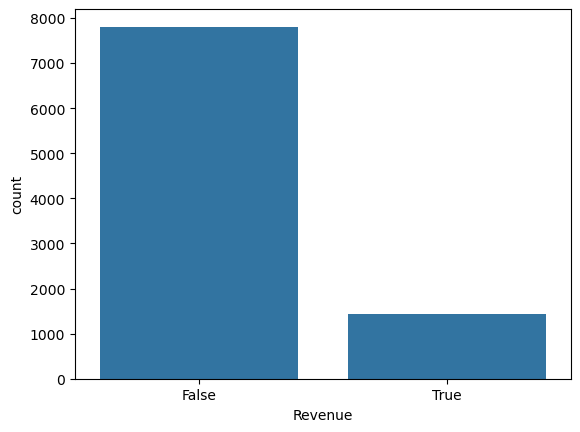

In [14]:
sns.countplot(x='Revenue', data=exp_data)
plt.show()

The target variable ``Revenue`` exhibits a clear class imbalance, with False representing the majority (7807 samples) and True the minority (1441 samples). Given this distribution, accuracy is not a reliable metric. Therefore, we will prioritize metrics like the F1-Score and utilize stratified splitting to maintain class proportions across training and test sets, ensuring the model is evaluated fairly on its ability to detect purchasing intent.

--- 

## Distribution of Features
Before investigating seperately the continuous and and categorical variables, let's see the correlation between different variables

### Correlation between features

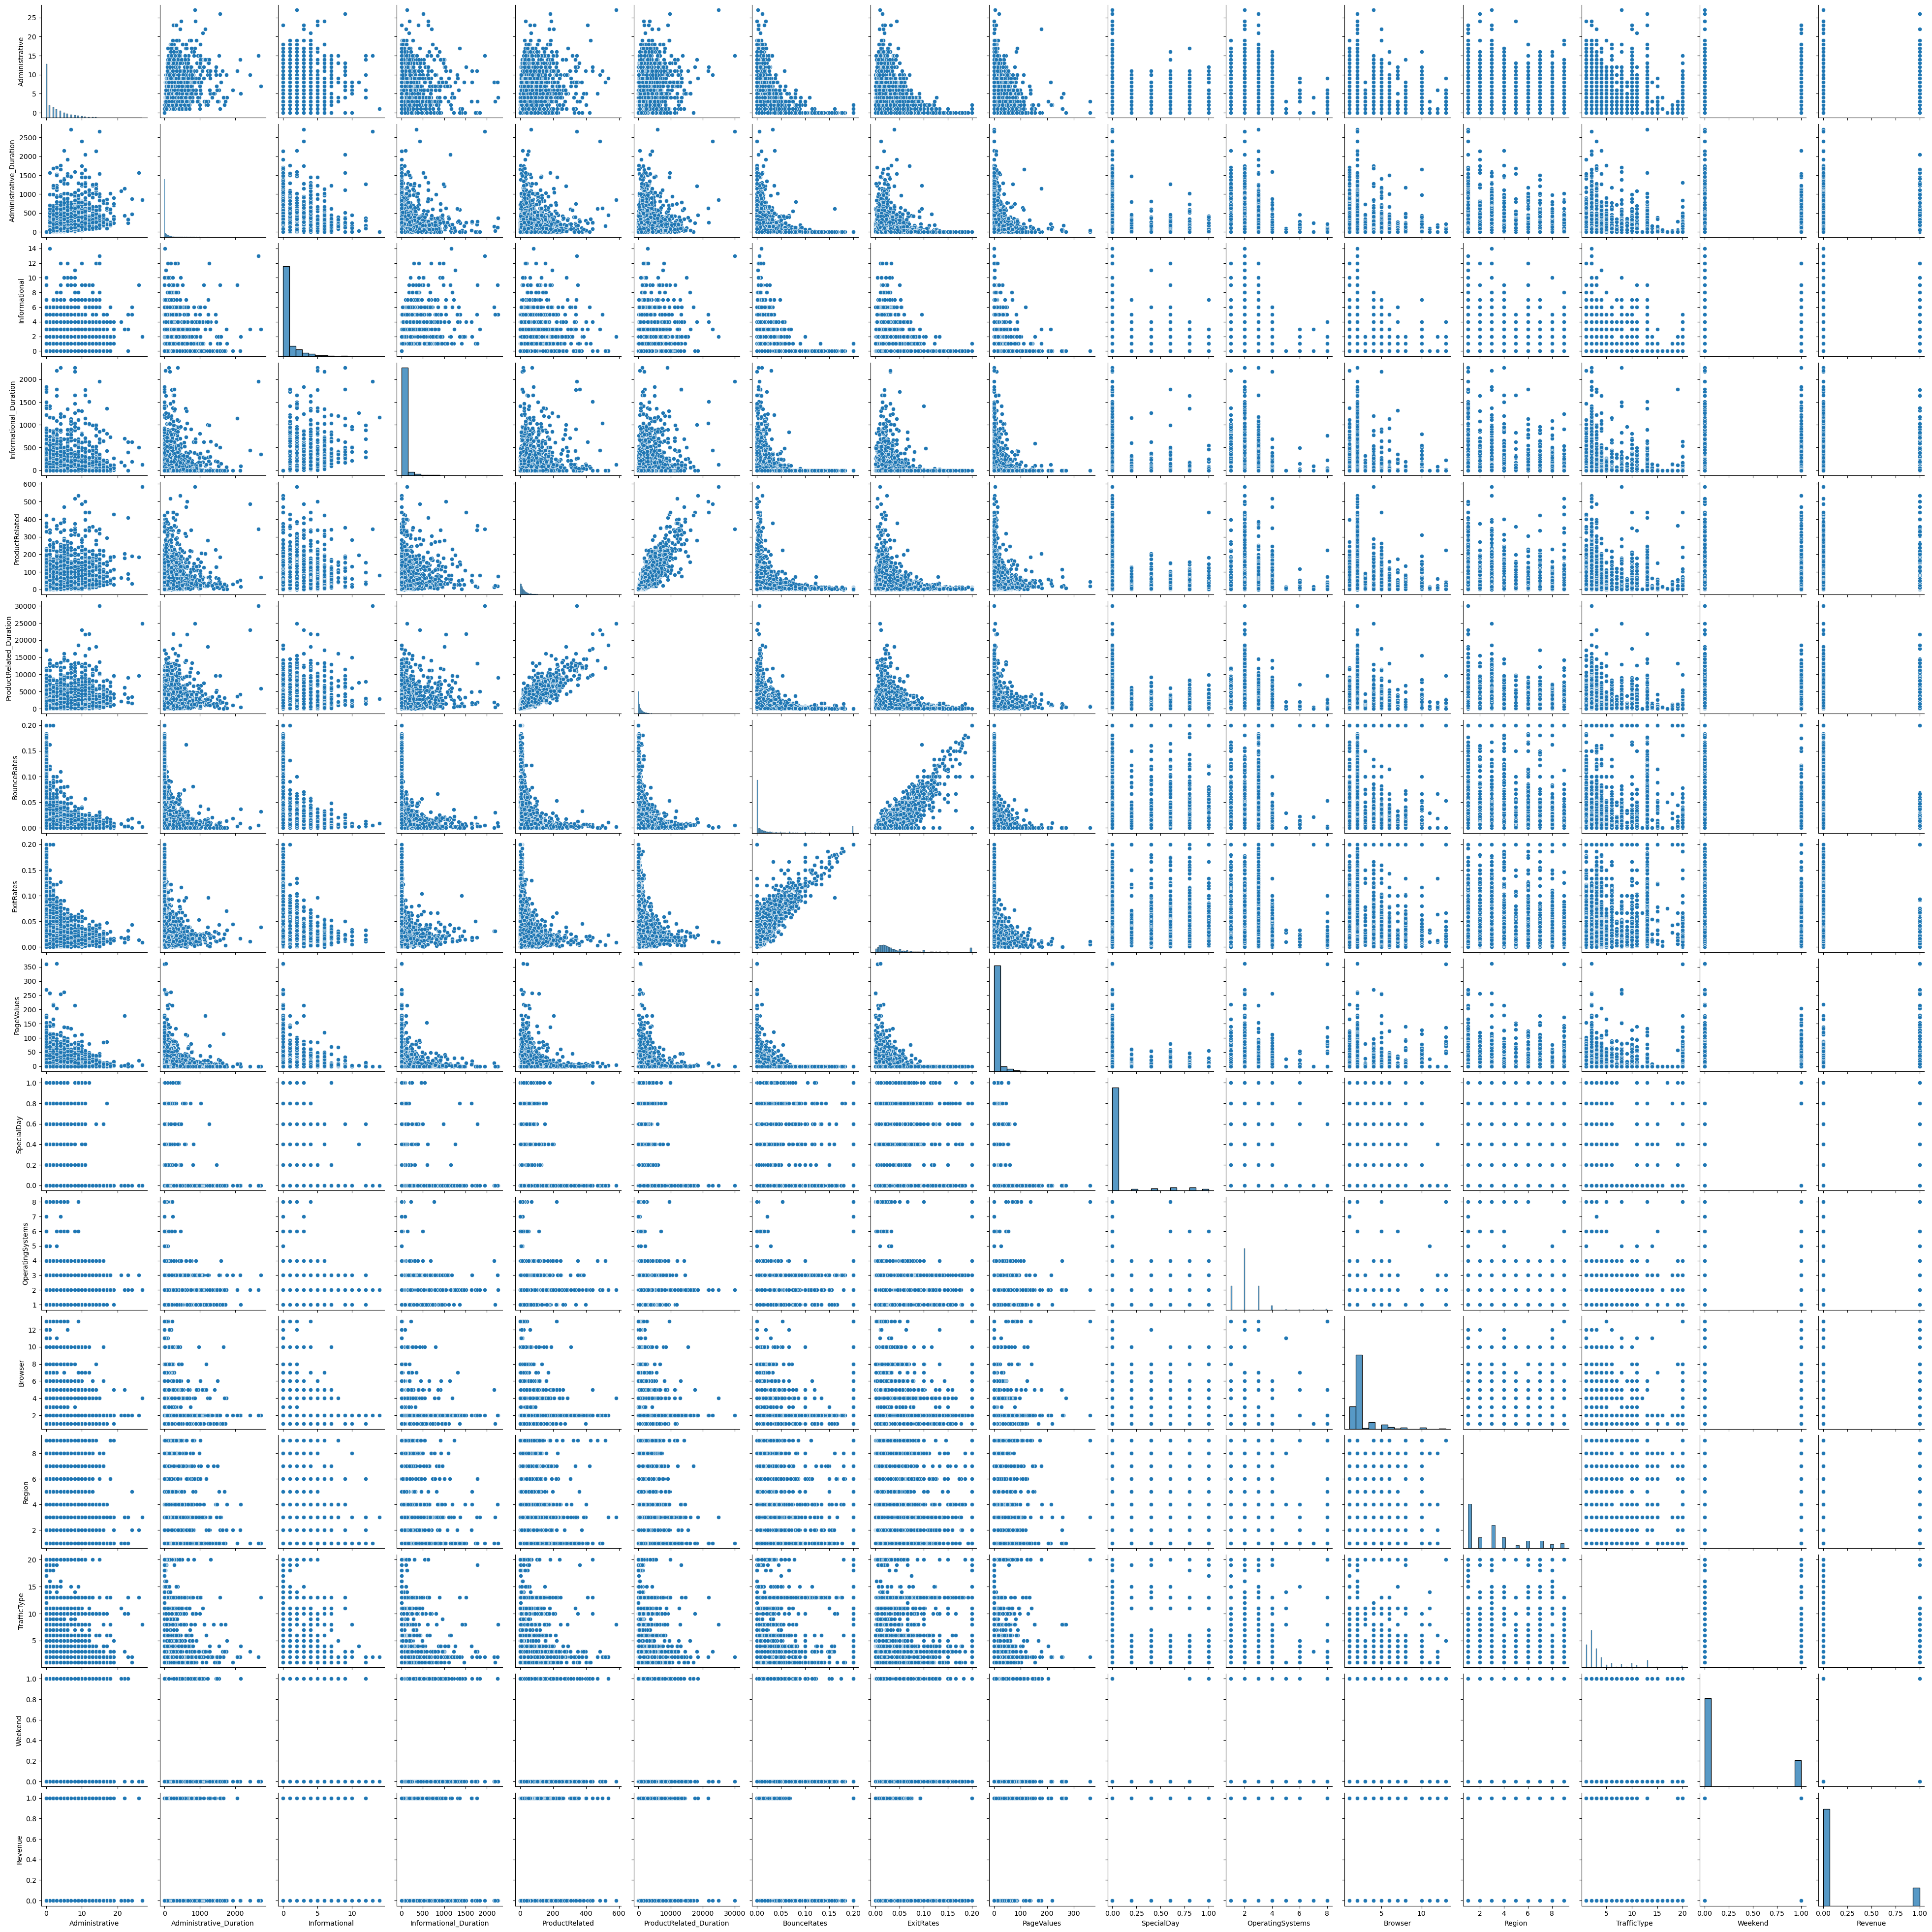

In [15]:
sns.pairplot(exp_data, height=2.5)
plt.show()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Revenue
Administrative,1.000000,0.611851,0.375773,0.258137,0.419721,0.380945,-0.224850,-0.309846,0.094717,-0.102648,0.028321,0.134150
Administrative_Duration,0.611851,1.000000,0.289336,0.218854,0.259107,0.303871,-0.145781,-0.207051,0.067182,-0.080183,0.014885,0.091469
Informational,0.375773,0.289336,1.000000,0.616967,0.352429,0.377018,-0.116810,-0.156937,0.042454,-0.052272,0.034639,0.093716
Informational_Duration,0.258137,0.218854,0.616967,1.000000,0.266616,0.320617,-0.075360,-0.103809,0.028986,-0.032154,0.028703,0.066165
ProductRelated,0.419721,0.259107,0.352429,0.266616,1.000000,0.873362,-0.208201,-0.294423,0.053836,-0.032640,0.021780,0.162163
ProductRelated_Duration,0.380945,0.303871,0.377018,0.320617,0.873362,1.000000,-0.198554,-0.269676,0.055034,-0.045060,0.010219,0.164373
BounceRates,-0.224850,-0.145781,-0.116810,-0.075360,-0.208201,-0.198554,1.000000,0.912628,-0.121093,0.074986,-0.050657,-0.152728
ExitRates,-0.309846,-0.207051,-0.156937,-0.103809,-0.294423,-0.269676,0.912628,1.000000,-0.175136,0.107706,-0.069067,-0.208109
PageValues,0.094717,0.067182,0.042454,0.028986,0.053836,0.055034,-0.121093,-0.175136,1.000000,-0.064241,0.004976,0.485376
SpecialDay,-0.102648,-0.080183,-0.052272,-0.032154,-0.032640,-0.045060,0.074986,0.107706,-0.064241,1.000000,-0.017286,-0.082262


<Axes: >

Text(0.5, 1.0, 'Feature Correlation Matrix')

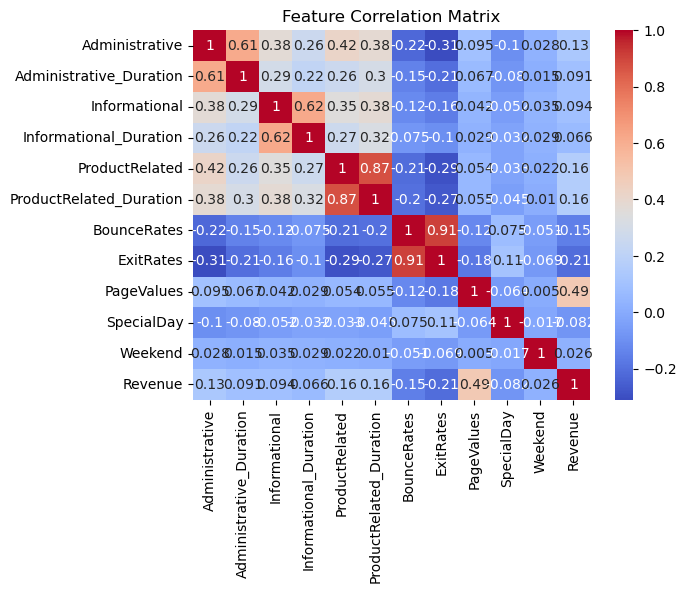

In [16]:
# We decided to remove nominal features in our correlation analysis
nominal_features = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType", "Month"]
corr = exp_data.drop(nominal_features, axis=1).corr()
corr

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

By observing the heatmap with the correlation between the continuous variable, we can boserve that:
- Some pairs (Administrative-Administrative_Duration, Product_based-Product_based_duration, ect.) are highly correlated features since they are measuring two sides of the same user behavior
- There is a moderate correlation between Revenue and PageValues, suggesting that Pagevalues can be a possible predictor of Revenue.
- Special day and weekend have very low correlation with all other features, likely representin gnoise in my data


Let's examine further the relationships of a selected subset of features with respect to ``Revenue``.

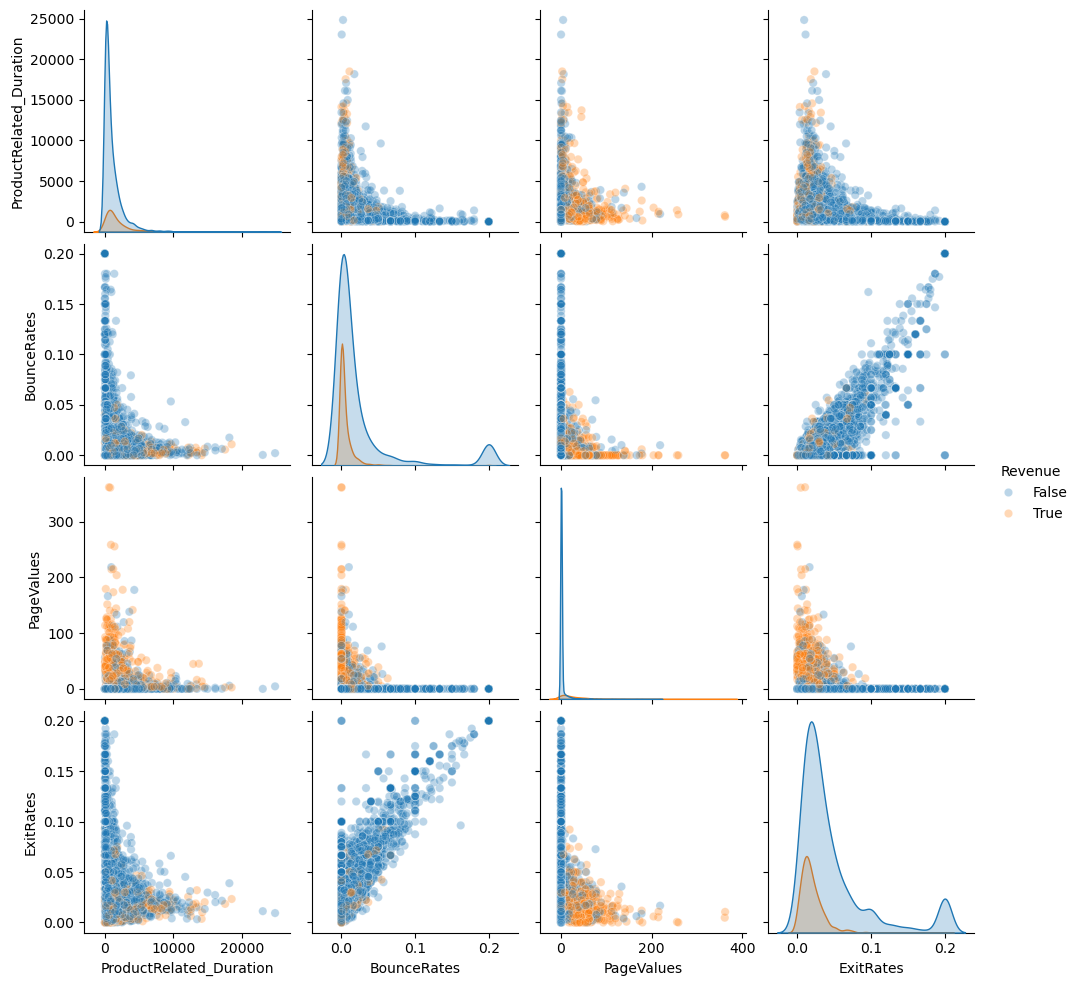

In [17]:
subset = ['ProductRelated_Duration', 'BounceRates', 'PageValues', 'ExitRates', 'Revenue']
sns.pairplot(exp_data[subset].dropna(), hue='Revenue', diag_kind='kde', plot_kws={'alpha':0.3})
plt.show()

#as expected highly correalted variable have a lienar relationshiè 

- The strong linear correlation between BounceRates and ExitRates confirms that these metrics capture nearly identical user disengagement behavior, suggesting redundancy in the feature set
- PageValues stands out as a discriminator with buying users showing higher values than the users who do not buy

### Continuous Features

<Axes: xlabel='Revenue', ylabel='Administrative'>

Text(0.5, 1.0, 'Boxplot of Administrative')

<Axes: xlabel='Revenue', ylabel='Administrative_Duration'>

Text(0.5, 1.0, 'Boxplot of Administrative_Duration')

<Axes: xlabel='Revenue', ylabel='Informational'>

...

Text(0.5, 1.0, 'Boxplot of BounceRates')

<Axes: xlabel='Revenue', ylabel='ExitRates'>

Text(0.5, 1.0, 'Boxplot of ExitRates')

<Axes: xlabel='Revenue', ylabel='PageValues'>

Text(0.5, 1.0, 'Boxplot of PageValues')

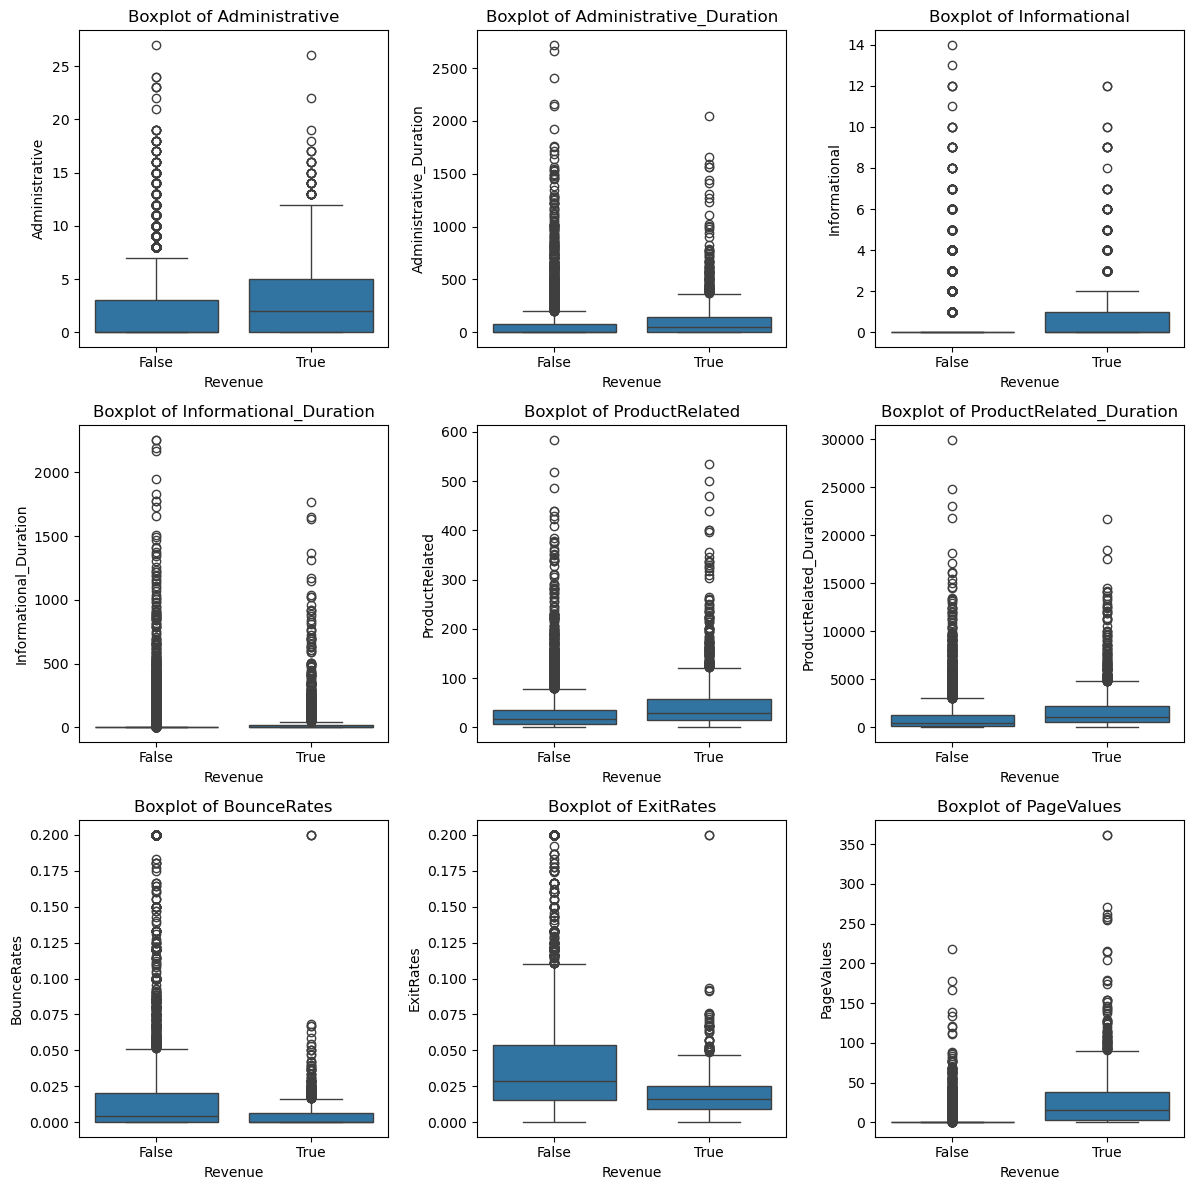

In [18]:
continuous = ['Administrative', 'Administrative_Duration', 'Informational',
             'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
             'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.4)

for i, name in enumerate(continuous):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.boxplot(data=exp_data, x="Revenue", y=name, ax=ax)
    ax.set_title("Boxplot of {}".format(name))

plt.tight_layout()
plt.show()

From the boxplots, it is interesting to see the boxplot of ``PageValues`` that the majority of users who do not generate revenue have ``PageValues`` near zero while the users that do generate revenue have high ``PageValues``. 
\
``BounceRates`` and ``ExitRates`` shows a very weak but interesting negative relationship with purchase behavior. Users who do not buy exhibit significantly higher and more volatile bounce and exit rates. Contrarily, customers who purchase tend to have a visible overall higher engagement
\
All of continuous features exhibit high concentration of outliers justifying a need for data scaling.


<Axes: xlabel='Administrative', ylabel='Count'>

Text(0.5, 1.0, 'Administrative')

<Axes: xlabel='Administrative_Duration', ylabel='Count'>

Text(0.5, 1.0, 'Administrative_Duration')

<Axes: xlabel='Informational', ylabel='Count'>

...

Text(0.5, 1.0, 'BounceRates')

<Axes: xlabel='ExitRates', ylabel='Count'>

Text(0.5, 1.0, 'ExitRates')

<Axes: xlabel='PageValues', ylabel='Count'>

Text(0.5, 1.0, 'PageValues')

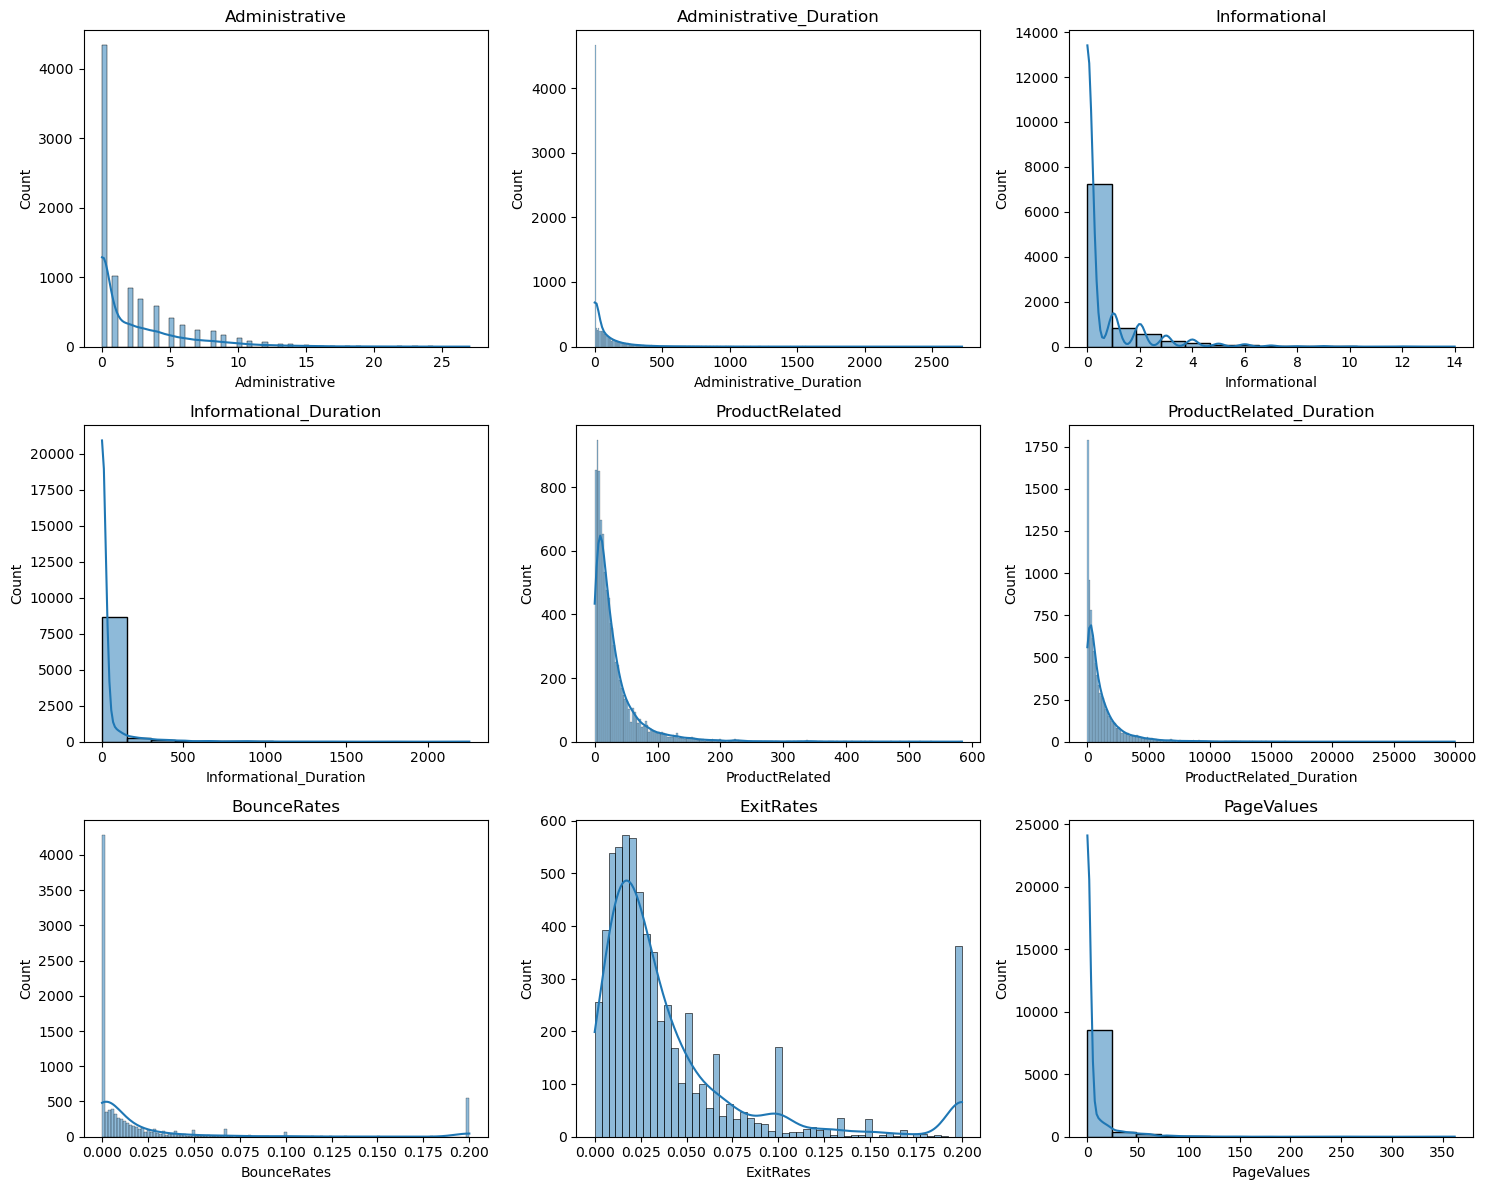

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), continuous):
    sns.histplot(exp_data[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Categorical Variables

In [20]:
categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
exp_data[categorical_columns] = exp_data[categorical_columns].astype("category")

# We encoded Month as an ordered category to capture seasonality
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_dtype = pd.CategoricalDtype(categories=month_order, ordered=True)
exp_data['Month'] = exp_data['Month'].astype(month_dtype)

categoricals = ["Month", "OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]

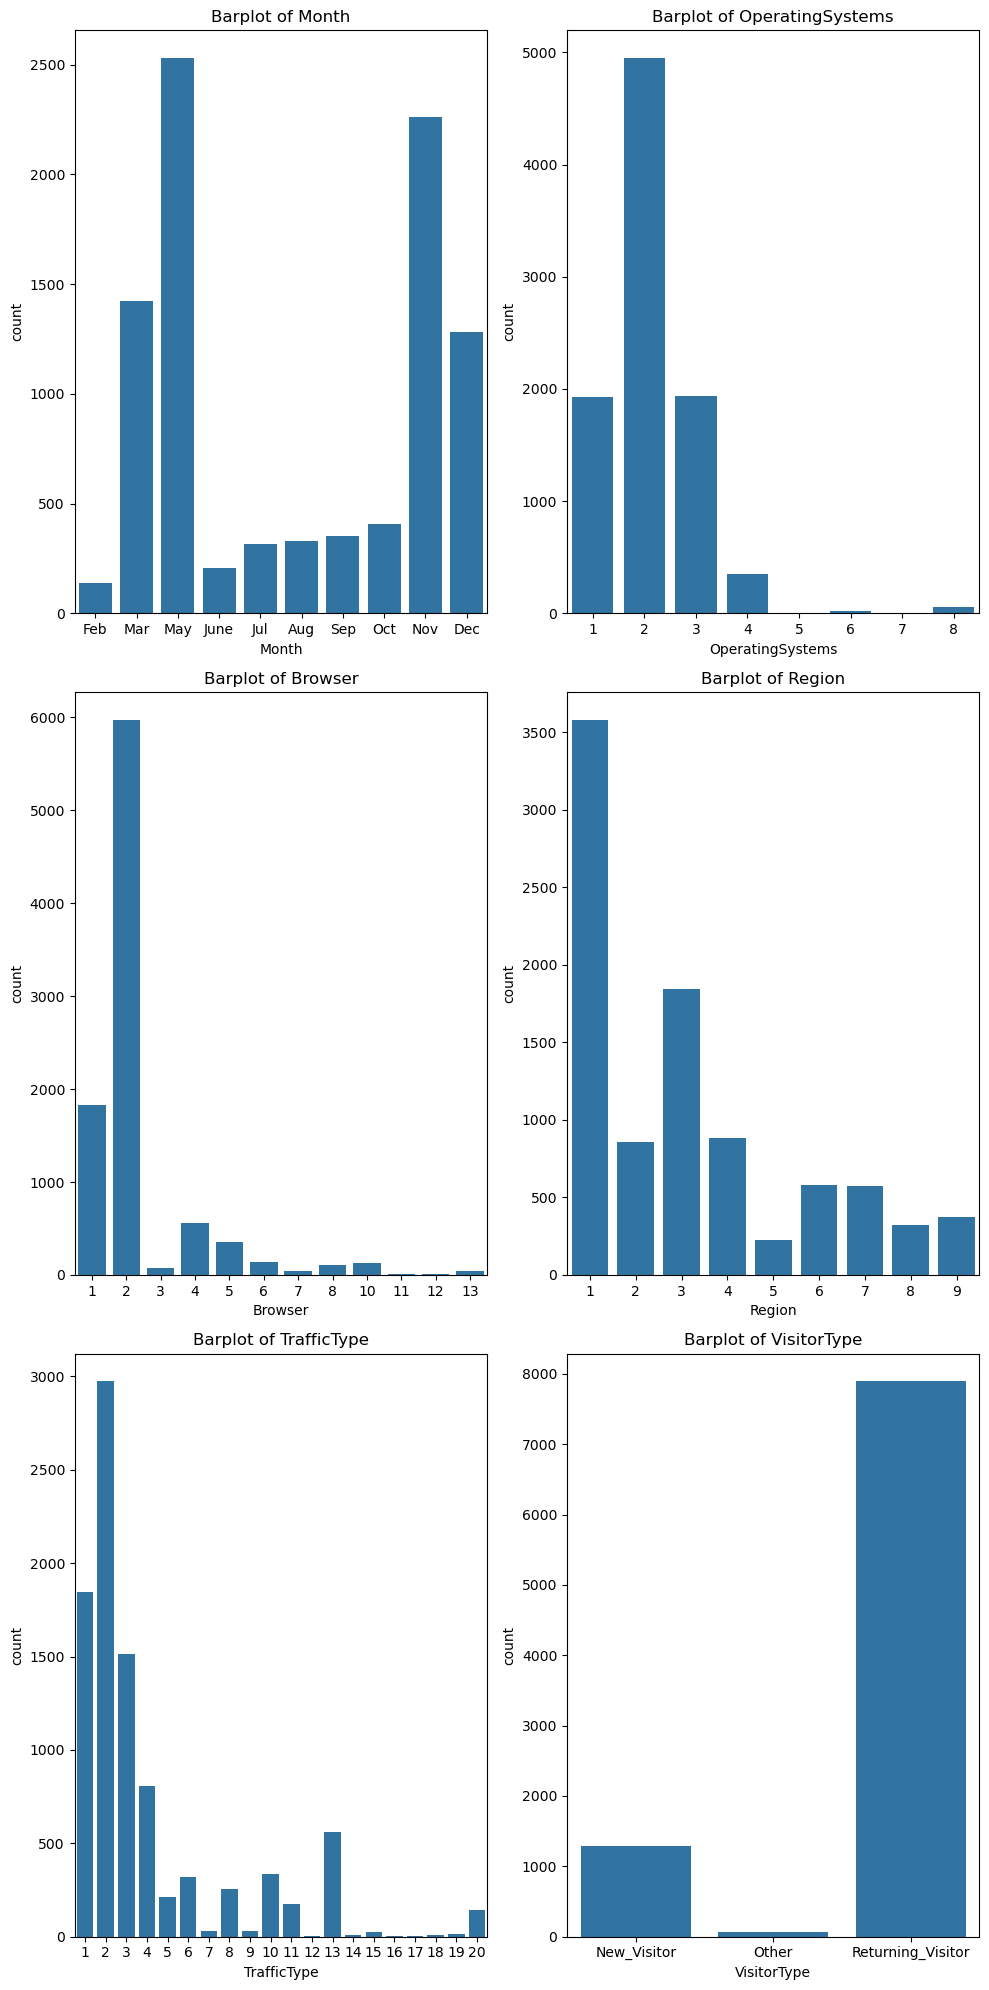

In [21]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 20))
for name in enumerate(categoricals):
    i, name = name
    sns.countplot(data=exp_data, x=name, ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title("Barplot of {}".format(name))

plt.tight_layout()
plt.show();

### Categorical variables w.r.t. ``Revenue``

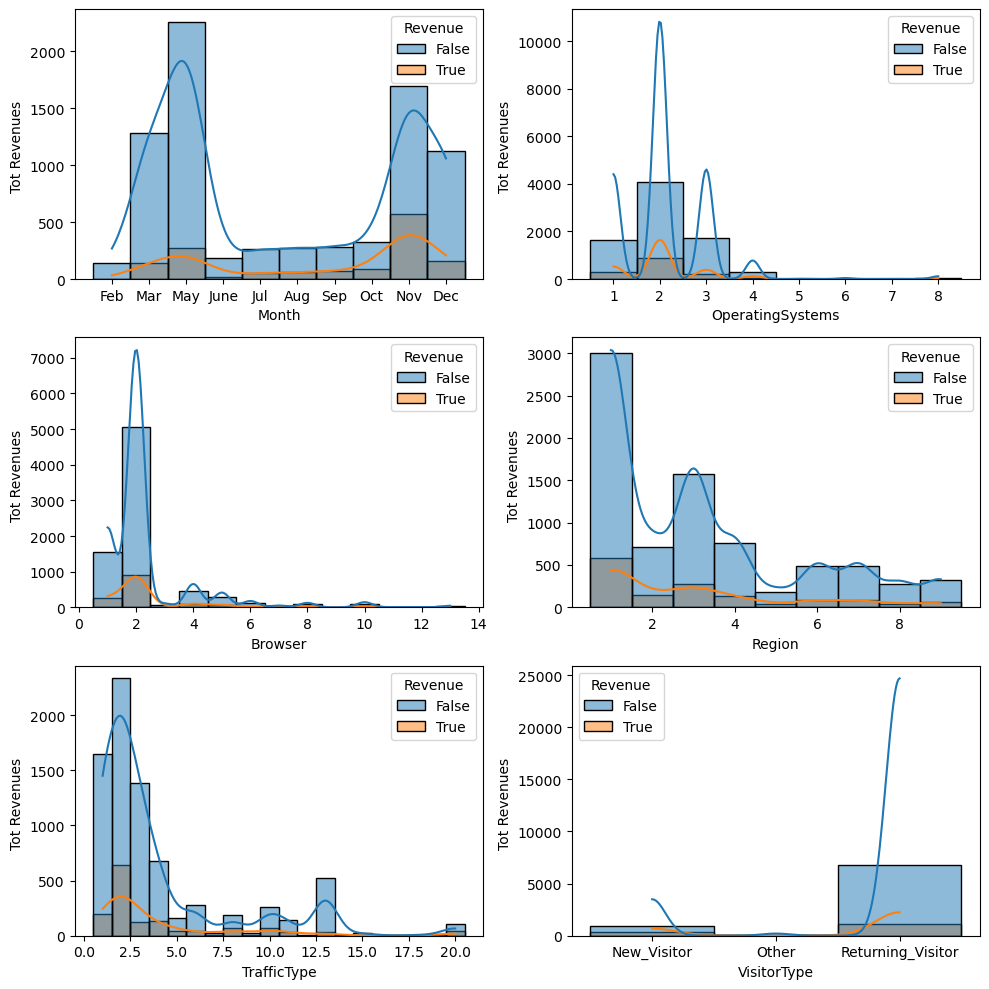

In [22]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
plt.subplots_adjust(hspace=0.4)

for i, categorical in enumerate(categoricals):
    ax = axes[i // 2, i % 2]  # Assign the correct axes to 'ax'
    sns.histplot(data=exp_data, x=categorical, hue="Revenue", kde=True, ax=ax)
    ax.set_xlabel(categorical)
    ax.set_ylabel("Tot Revenues ")

plt.tight_layout()
plt.show();

It is interesting to see clear seasonality in user behavior: May has a very high volume of non purchasing users while November shows an increase in purchases (likely holidays)
\
Returning visitors account for majority of revenue generation. Similarly, System 2 and Browser 2 are the most popular technical platforms.
\
Region distribution is unequal with region 1 dominating the traffic. 
The majority of site visitors arrive via a small number of primary traffic channels suggesting that only few sources are significant drivers of purchase. 



---
---

## 1.2 Regression

To recover the missing values in ``ExitRates``, we decided to evaluate different regressors.

### Encoding
Before proceeding, encoding is necessary to have a reliable model

In [23]:
#For TRAINING set
#one-hot encoing for 'Month'
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "June": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
} 
train_data['Month'] = train_data['Month'] .map(month_map)
train_data = pd.get_dummies(train_data, columns=["OperatingSystems","Browser","Region","TrafficType","VisitorType"])
train_data["Revenue"] = train_data["Revenue"].astype(int)
train_data["Weekend"] = train_data["Weekend"].astype(int)
train_data["month_sin"] = np.sin(2 * np.pi * train_data['Month'] / 12)
train_data["month_cos"] = np.cos(2 * np.pi * train_data['Month'] / 12)

#For TEST set
test_data['Month'] = test_data['Month'] .map(month_map)
test_data = pd.get_dummies(test_data, columns=["OperatingSystems","Browser","Region","TrafficType","VisitorType"])
test_data["Revenue"] = test_data["Revenue"].astype(int)
test_data["Weekend"] = test_data["Weekend"].astype(int)
test_data["month_sin"] = np.sin(2 * np.pi * test_data['Month'] / 12)
test_data["month_cos"] = np.cos(2 * np.pi * test_data['Month'] / 12)

In [24]:
#re-allinging in case columns between training and test are not aligned
#saving the columns
train_cols = train_data.columns
#reallining: 
test_data = test_data.reindex(columns=train_cols, fill_value=0)

In [25]:
train_data.isna().sum().sort_values(ascending=False)
test_data.isna().sum().sort_values(ascending=False)

train_data.columns

ExitRates         2782
Administrative       0
TrafficType_1        0
TrafficType_7        0
TrafficType_6        0
                  ... 
Browser_8            0
Browser_10           0
Browser_11           0
Browser_12           0
month_cos            0
Length: 67, dtype: int64

ExitRates         917
Administrative      0
TrafficType_1       0
TrafficType_7       0
TrafficType_6       0
                 ... 
Browser_8           0
Browser_10          0
Browser_11          0
Browser_12          0
month_cos           0
Length: 67, dtype: int64

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'Weekend', 'Revenue', 'OperatingSystems_1', 'OperatingSystems_2',
       'OperatingSystems_3', 'OperatingSystems_4', 'OperatingSystems_5',
       'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8',
       'Browser_1', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5',
       'Browser_6', 'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11',
       'Browser_12', 'Browser_13', 'Region_1', 'Region_2', 'Region_3',
       'Region_4', 'Region_5', 'Region_6', 'Region_7', 'Region_8', 'Region_9',
       'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4',
       'TrafficType_5', 'TrafficType_6', 'TrafficType_7', 'TrafficType_8',
       'TrafficType_9', 'TrafficType_10', 'TrafficType_11', 'TrafficType_12',
       'TrafficType_13', 'TrafficType_

## Regression

To predict ``ExitRates`` missing values, we trained different regression algorithms:
- Linear regression
- Ridge
- Lasso
- Random Forest

In [26]:
copied_train = train_data[train_data['ExitRates'].notna()]

We exclude Revenue from the regression features when predicting Exit Rate, since Revenue is the target variable for a separate downstream classification task; including it here would let the recovered Exit Rate values indirectly encode information about Revenue, creating a form of label leakage once Exit Rate is later used as a feature to predict Revenue itself.

In [27]:
X = copied_train.drop(['ExitRates', 'Revenue'], axis=1)
y = copied_train['ExitRates']

print(X.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'PageValues', 'SpecialDay', 'Month', 'Weekend',
       'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3',
       'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6',
       'OperatingSystems_7', 'OperatingSystems_8', 'Browser_1', 'Browser_2',
       'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7',
       'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13',
       'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6',
       'Region_7', 'Region_8', 'Region_9', 'TrafficType_1', 'TrafficType_2',
       'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_6',
       'TrafficType_7', 'TrafficType_8', 'TrafficType_9', 'TrafficType_10',
       'TrafficType_11', 'TrafficType_12', 'TrafficType_13', 'TrafficType_14',
       'TrafficType_15', '

In [28]:
# We will compare different regression models using MSE and R2 so we define them here
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer

r2_score = make_scorer(r2_score, greater_is_better=True)
mean_squared_error = make_scorer(mean_squared_error, greater_is_better=True)


results = {}

### Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression 

MultipleRegression = LinearRegression(fit_intercept= True)
scores_MR = cross_val_score(MultipleRegression, X, y, cv = 5, scoring=mean_squared_error)
scores_MR
results['MultipleRegression'] = (float(scores_MR.mean().round(4)), float(scores_MR.std().round(4)))

array([0.00040549, 0.00030345, 0.00032661, 0.00031313, 0.00027095])

### Lasso

In [30]:
#3.Lasso:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(random_state=42))
])

param_grid = {
    'lasso__alpha': np.logspace(-4, 1, 50)
}

# Inner CV: seleziona il miglior alpha
grid_lasso = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)

# Outer CV: valuta le performance in modo onesto (nested CV)
scores_lasso = cross_val_score(grid_lasso, X, y, cv=5, scoring= mean_squared_error)
results['Lasso'] = (float(scores_lasso.mean().round(4)), float(scores_lasso.std().round(4)))

### Ridge Regression

In [31]:
#4. Ridge Regression
from sklearn.linear_model import Ridge


pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=42))
])

param_grid_ridge = {
    'ridge__alpha': np.logspace(-4, 1, 50)
}

# Inner CV: seleziona il miglior alpha
grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)

# Outer CV: valuta le performance in modo onesto (nested CV)
scores_ridge = cross_val_score(grid_ridge, X, y, cv=5, scoring=mean_squared_error)
results['Ridge'] = (float(scores_ridge.mean().round(4)), float(scores_ridge.std().round(4)))

### Random Forest

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# We decided to comment the GridSearchCV since it runs for more than 10 mins.....
""" param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)
scores_rf = cross_val_score(
    grid_rf,
    X,
    y,
    cv=5,
    scoring= mean_squared_error
)

results['RandomForest'] = (
    float(scores_rf.mean().round(4)),
    float(scores_rf.std().round(4))
) """

' param_grid = {\n    "n_estimators": [100, 200, 500],\n    "max_depth": [10, 20, None],\n    "min_samples_leaf": [1, 2, 5],\n    "max_features": ["sqrt", 0.5]\n}\n\ngrid_rf = GridSearchCV(\n    RandomForestRegressor(random_state=42),\n    param_grid=param_grid,\n    cv=5,\n    scoring= mean_squared_error,\n    n_jobs=-1\n)\nscores_rf = cross_val_score(\n    grid_rf,\n    X,\n    y,\n    cv=5,\n    scoring= mean_squared_error\n)\n\nresults[\'RandomForest\'] = (\n    float(scores_rf.mean().round(4)),\n    float(scores_rf.std().round(4))\n) '

In [33]:
# Using the best parameter found previously
grid_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

scores_rf = cross_val_score(
    grid_rf,
    X,
    y,
    cv=5,
    scoring= mean_squared_error
)

results['RandomForest'] = (
    float(scores_rf.mean().round(4)),
    float(scores_rf.std().round(4))
)

## Results for regression

In [34]:
pd.DataFrame(results, ['MSE', 'std'])

,MultipleRegression,Lasso,Ridge,RandomForest
MSE,0.0003,0.0023,0.0003,0.0002
std,0.0000,0.0002,0.0000,0.0000


Text(0, 0.5, 'Mean Squared Error')

Text(0.5, 1.0, 'Confronto modelli: MSE (mean ± std)')

[Text(0, 0, 'MultipleRegression'),
 Text(1, 0, 'Lasso'),
 Text(2, 0, 'Ridge'),
 Text(3, 0, 'RandomForest')]

Text(0.0, 0.0003, '0.0003')

Text(1.0, 0.0023, '0.0023')

Text(2.0, 0.0003, '0.0003')

Text(3.0, 0.0002, '0.0002')

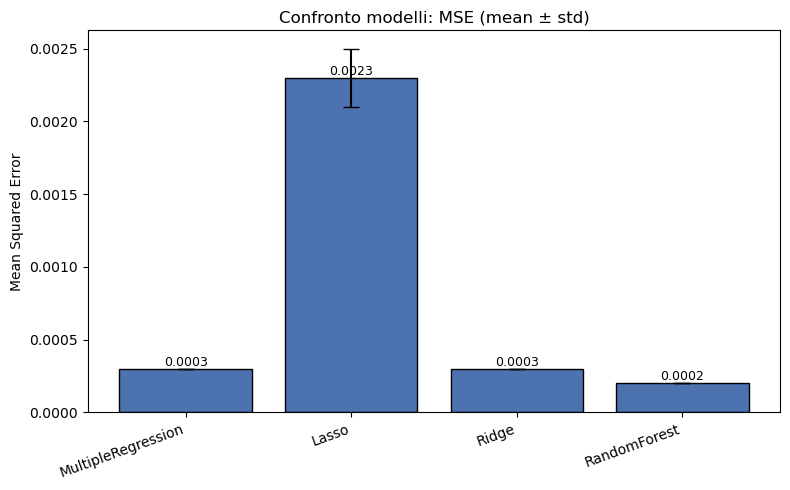

In [35]:
#results for regression algorithms:
keys = list(results.keys())
means = [v[0] for v in results.values()]
stds = [v[1] for v in results.values()]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(keys, means, yerr=stds, capsize=6, color="#4C72B0", edgecolor="black")

ax.set_ylabel("Mean Squared Error")
ax.set_title("Confronto modelli: MSE (mean ± std)")
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=20, ha="right")

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{mean:.4f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("mse_barplot.png", dpi=150)
plt.show()


To select optimal predictive model, we compared the MSE across our regressors. The random forest outperformed linear methods yielding the lowest average error. To address missing values, we decided to implement an iterative predictive imputation strategy using a Random Forest regressor.  The only drawback for the random forest approach is its complexity but since our primary goal is to maximize the accuracy of the filled data, we chose predictive robustness over interpretability.

## Fitting the best model

In [36]:
# Remove comment if you want to run GridSearchCV
""" grid_rf.fit(X, y)

print(grid_rf.best_params_)
print(grid_rf.best_score_) """

""" #building the random forest model with the best parameters
best_model = RandomForestRegressor(
    **grid_rf.best_params_, #selecting the best parameters
    random_state=42,
    n_jobs=-1
)

#fitting the model 
best_model.fit(X,y) """

' grid_rf.fit(X, y)\n\nprint(grid_rf.best_params_)\nprint(grid_rf.best_score_) '

' #building the random forest model with the best parameters\nbest_model = RandomForestRegressor(\n    **grid_rf.best_params_, #selecting the best parameters\n    random_state=42,\n    n_jobs=-1\n)\n\n#fitting the model \nbest_model.fit(X,y) '

In [37]:
# Comment this block of code if GirdSearchCV was runned
best_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

best_model.fit(X,y)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

----
---
---

# Task 2
_Use the regression model trained at the previous step to recover the Exit Rate by predicting its value for each missing sample on the train and test set. Build a classification model to predict whether an online shopper is likely to make a purchase. Perform feature selection, compare different algorithms, and identify the one that works the best on this dataset. Finally, test the best algorithm’s performance on the provided test set. Determine whether a model built using the Exit Rate information is better than a model built using the remaining features._

**2.1 Recovering ExitRates** \
**2.2 Classification with all features** \
**2.3 Feature selection**:
- Logistic lasso
- Forward Feature Selection
- Random Forest 

**2.4 Classification with selected features** \
**2.5 Performance on test set**

## 2.1 Filling NAs 

### Filling NAs in Training set

In [38]:
#filling the NaN:
print('before')
train_data.isna().sum().sort_values(ascending=False) 
#selecting the NaN value that we are gonna predict with all the feature present in the dataset
X_test = train_data.loc[
    train_data['ExitRates'].isna(),
    X.columns
]
#computing the prediciton given that X
pred = best_model.predict(X_test)
#assigning the prediction to the correspondet NaN in the training dataset:
train_data.loc[train_data['ExitRates'].isna(), 'ExitRates'] = pred
print('after')
#after
train_data.isna().sum().sort_values(ascending=False) 

before


ExitRates         2782
Administrative       0
TrafficType_1        0
TrafficType_7        0
TrafficType_6        0
                  ... 
Browser_8            0
Browser_10           0
Browser_11           0
Browser_12           0
month_cos            0
Length: 67, dtype: int64

after


Administrative    0
TrafficType_9     0
Region_4          0
Region_5          0
Region_6          0
                 ..
Browser_8         0
Browser_10        0
Browser_11        0
Browser_12        0
month_cos         0
Length: 67, dtype: int64

### Filling NAs in test set

We train the random forest with all the observation and our dataset to have a complete model to be used for predicting the 'Exit Rate' feature in the test set. *The following block of code is redundant if Random Forest was runned without GridSearch.*


In [39]:
X_full = train_data[X.columns]
y_full = train_data['ExitRates']

best_model.fit(X_full,y_full)

print(X.shape, X_full.shape)
print(X.equals(X_full) if hasattr(X, 'equals') else np.array_equal(X, X_full))

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

(6466, 65) (9248, 65)
False


In [40]:
#filling the NaN in the test set:
X_test = test_data.loc[
    test_data['ExitRates'].isna(),
    X.columns
]
#computing the prediciton given that X
pred = best_model.predict(X_test)
#assigning the prediction to the correspondet NaN in the training dataset:
test_data.loc[test_data['ExitRates'].isna(), 'ExitRates'] = pred
print('after')
#after
test_data.isna().sum().sort_values(ascending=False) 

after


Administrative    0
TrafficType_9     0
Region_4          0
Region_5          0
Region_6          0
                 ..
Browser_8         0
Browser_10        0
Browser_11        0
Browser_12        0
month_cos         0
Length: 67, dtype: int64

--- 
---

# 2.2 Classification

For ``Revenue`` prediction we decided to use different regression algorithms:
- Logistic regression
- LDA
- QDA
- KNN
- SVM

We decided to compare their performances before with all features and then subsequently we performed feature selection to compare whether their performances improved.

In [41]:
from collections import OrderedDict
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
from sklearn.svm import SVC

X = train_data.drop(['Revenue'], axis=1)
y = train_data['Revenue']

X.columns


Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'Weekend', 'OperatingSystems_1', 'OperatingSystems_2',
       'OperatingSystems_3', 'OperatingSystems_4', 'OperatingSystems_5',
       'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8',
       'Browser_1', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5',
       'Browser_6', 'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11',
       'Browser_12', 'Browser_13', 'Region_1', 'Region_2', 'Region_3',
       'Region_4', 'Region_5', 'Region_6', 'Region_7', 'Region_8', 'Region_9',
       'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4',
       'TrafficType_5', 'TrafficType_6', 'TrafficType_7', 'TrafficType_8',
       'TrafficType_9', 'TrafficType_10', 'TrafficType_11', 'TrafficType_12',
       'TrafficType_13', 'TrafficType_14', 'Traff

## Classification with all features

/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


,model,accuracy,accuracy_std,f1,f1_std,roc_auc,roc_auc_std
0,LDA,0.877919,0.005002,0.457162,0.027934,0.894930,0.012910
1,QDA,0.184152,0.023583,0.274860,0.006509,0.789827,0.015109
2,Logistic Regression,0.853806,0.006629,0.608624,0.016076,0.901104,0.012231
3,KNN,0.861051,0.006141,0.295963,0.027507,0.782658,0.015033
4,KNN + StandardScaler,0.852941,0.002411,0.146594,0.019983,0.745940,0.018689
5,KNN + MinMaxScaler,0.842993,0.002716,0.052157,0.010601,0.676133,0.014084
6,SVC (best parameters),0.832180,0.003930,0.372424,0.021413,0.776499,0.009932


Text(0, 0.5, 'Score')

Text(0.5, 1.0, 'Model comparison with all features')

(0.0, 1.0)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'LDA'),
  Text(1, 0, 'QDA'),
  Text(2, 0, 'Logistic Regression'),
  Text(3, 0, 'KNN'),
  Text(4, 0, 'KNN + StandardScaler'),
  Text(5, 0, 'KNN + MinMaxScaler'),
  Text(6, 0, 'SVC (best parameters)')])

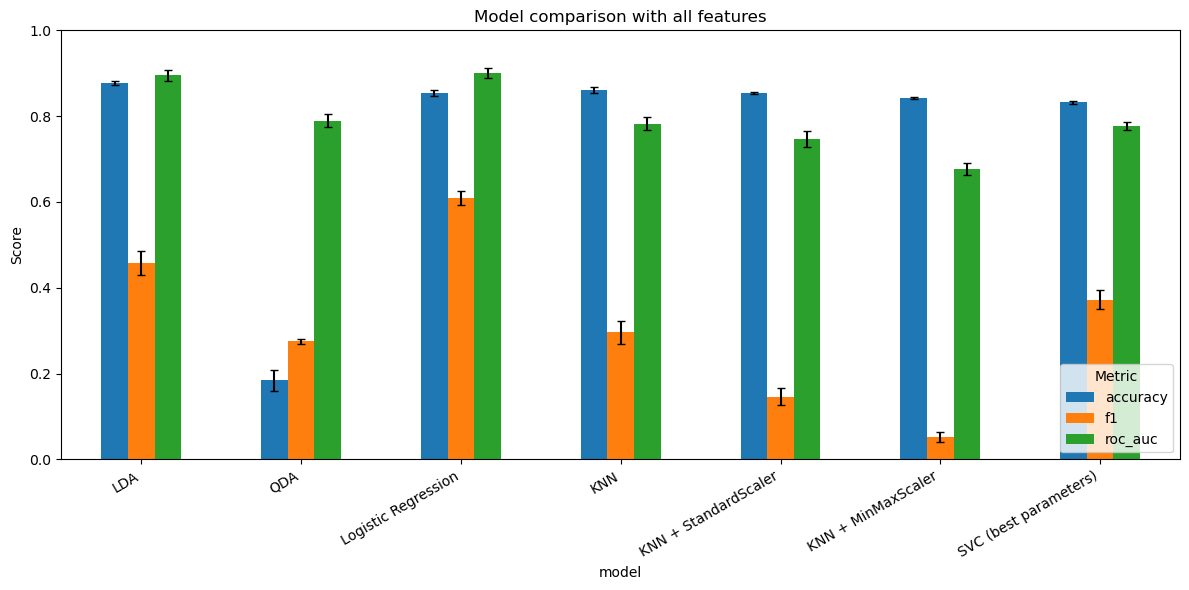

In [42]:
# We defined the models we use
lda = LDA()
qda = QDA()

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

knn = KNeighborsClassifier(n_neighbors=11)

knn_std = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=16))
])

knn_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=17))
])

SVC_best = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        C=10,
        gamma=0.1,
        class_weight='balanced'
    ))
])

models = OrderedDict([
    ('LDA', lda),
    ('QDA', qda),
    ('Logistic Regression', log_reg),
    ('KNN', knn),
    ('KNN + StandardScaler', knn_std),
    ('KNN + MinMaxScaler', knn_minmax),
    ('SVC (best parameters)', SVC_best)
])

# Compare models (CV only)
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_list = []
for name, model in models.items():
    cv_res = cross_validate(
        model, X, y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    row = {'model': name}
    for metric in scoring:
        row[metric] = cv_res[f'test_{metric}'].mean()
        row[f'{metric}_std'] = cv_res[f'test_{metric}'].std()
    results_list.append(row)

results = pd.DataFrame(results_list)
results

results_plot = results.set_index('model')

# Colonne delle metriche (senza le colonne _std)
metric_cols = [c for c in results_plot.columns if not c.endswith('_std')]
std_cols = [c + '_std' for c in metric_cols]

means = results_plot[metric_cols]
stds = results_plot[std_cols]
stds.columns = metric_cols  # rinomino per allineare gli indici con means

ax = means.plot(
    kind='bar',
    figsize=(12, 6),
    yerr=stds,
    capsize=3
)
plt.ylabel("Score")
plt.title("Model comparison with all features")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', title='Metric')
plt.tight_layout()
plt.show()

---

# 2.3 Feature Selection

We need to build a classfication using only the most relevant feature, so before trying diffent clasfication methods to predict the 'Revenue' we will first select the most important features that are usefull in our problem. We used:
- Logistic Regression L1 (Lasso)
- Forward Feature selection
- Random Forest 

### Lasso

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#cross validation to decide with penalty value is the best to use
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
C_scores = {}

for C in C_values:

    model = Pipeline([('scaler', StandardScaler()),
                      ('lasso', LogisticRegression(
                                penalty="l1",
                                C=C,
                                solver="liblinear",   
                                max_iter=1000,
                                class_weight="balanced" ))]) 
    # class_weight="balanced" to take into account the fact that the class 1 for revenue is not balanced

    scores= cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring= "f1")
    
    model.fit(X, y)
    
    lasso_model = model.named_steps['lasso']

    n_zero = np.sum(lasso_model.coef_ == 0) 

    C_scores[C] = (float(scores.mean().round(4)), float(n_zero))
print(C_scores)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                                    penalty='l1', solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=10, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=100, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

{0.001: (0.6519, 64.0), 0.01: (0.6324, 49.0), 0.1: (0.6064, 11.0), 1: (0.6005, 4.0), 10: (0.5983, 4.0), 100: (0.5983, 0.0)}


### Forward Feature Selection

In [44]:
#forward feature selection
from sklearn.feature_selection import SequentialFeatureSelector

sfs_forward = SequentialFeatureSelector(
    MultipleRegression,
    n_features_to_select= 'auto',       
    direction="forward",
    scoring= 'neg_mean_squared_error',                  
    cv=5,                          
    n_jobs=-1                       
)

sfs_forward.fit(X, y)
selected_mask = sfs_forward.get_support()
selected_indices = np.where(selected_mask)[0]

print(selected_indices)

selected_features_FFS = X.columns[selected_mask]
print(list(selected_features_FFS))

SequentialFeatureSelector(estimator=LinearRegression(), n_jobs=-1,
                          scoring='neg_mean_squared_error')

[ 4  5  6  7  8 10 13 17 18 21 22 25 33 37 39 40 41 43 44 46 49 50 51 52
 53 54 55 56 57 59 61 64 65]
['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'Month', 'OperatingSystems_2', 'OperatingSystems_6', 'OperatingSystems_7', 'Browser_2', 'Browser_3', 'Browser_6', 'Region_2', 'Region_6', 'Region_8', 'Region_9', 'TrafficType_1', 'TrafficType_3', 'TrafficType_4', 'TrafficType_6', 'TrafficType_9', 'TrafficType_10', 'TrafficType_11', 'TrafficType_12', 'TrafficType_13', 'TrafficType_14', 'TrafficType_15', 'TrafficType_16', 'TrafficType_17', 'TrafficType_19', 'VisitorType_New_Visitor', 'month_sin', 'month_cos']


In [45]:
#we don't have a lot of diverty in the f1 for each model, so taking into account the fact that we have a lot of variable we will go with the value of C = 0.01 that is
#between all the value that we trying in order to obtain a much simpler model to compare:
#even if is not the best accuracy we choose a model with only the essential feature in order to have something more interpretable

Logist_Lasso = Pipeline([('scaler', StandardScaler()),
                      ('lasso', LogisticRegression(
                                penalty="l1",
                                C=0.01,
                                solver="liblinear",   
                                max_iter=1000,
                                class_weight="balanced"))])

Logist_Lasso.fit(X,y)

lasso_model = Logist_Lasso.named_steps['lasso']

coef = lasso_model.coef_.ravel()

selected_features_LASSO = X.columns[np.abs(coef) > 1e-6]
print(list(selected_features_LASSO))

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

['Administrative', 'Informational', 'ProductRelated', 'ProductRelated_Duration', 'ExitRates', 'PageValues', 'Region_9', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_8', 'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'VisitorType_New_Visitor', 'month_sin', 'month_cos']


In [46]:
import pandas as pd
from sklearn.feature_selection import SelectFromModel

# Assuming you have something like:
# rf = RandomForestRegressor(random_state=42)
grid_rf.fit(X, y)

importances = pd.Series(grid_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Select features above the median importance (or 'mean', or a specific float threshold)
selector = SelectFromModel(grid_rf, threshold='median', prefit=True)
selected_mask = selector.get_support()

selected_features_rf = X.columns[selected_mask].tolist()
print(selected_features_rf)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'Weekend', 'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3', 'Browser_1', 'Browser_2', 'Browser_4', 'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_6', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_8', 'TrafficType_10', 'VisitorType_New_Visitor', 'VisitorType_Returning_Visitor', 'month_sin', 'month_cos']


In [47]:
feature_sets_clf = {
    'All features': X.columns.tolist(),
    'RF selected': selected_features_rf,
    'Lasso-LR selected': selected_features_LASSO,
    'Forward selected': selected_features_FFS,
}

len(selected_features_rf)
len(selected_features_FFS)
len(selected_features_LASSO)

print('ExitRates' in selected_features_LASSO)
print('ExitRates' in selected_features_rf)

33

33

17

True
True


In [48]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

# Plain (unscaled) models — will get StandardScaler applied automatically in the loop below
plain_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'SVM': SVC(class_weight='balanced', probability=True),
    'KNN': KNeighborsClassifier(),
}

# Models that already come with their OWN scaler baked in — used as-is, no extra wrapping
prebuilt_pipelines = {
    'KNN + StandardScaler': Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),
    'KNN + MinMaxScaler': Pipeline([
        ('scaler', MinMaxScaler()),
        ('knn', KNeighborsClassifier())
    ]),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc']

results_clf_fs = []

for fs_name, feats in feature_sets_clf.items():
    X_subset = X[feats]

    # Plain models: wrap in a fresh StandardScaler pipeline
    for model_name, model in plain_models.items():
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        scores = cross_validate(pipe, X_subset, y, cv=skf, scoring=scoring, n_jobs=-1)
        results_clf_fs.append({
            'Feature Set': fs_name,
            'Model': model_name,
            'n_features': len(feats),
            'Accuracy': scores['test_accuracy'].mean(),
            'F1': scores['test_f1'].mean(),
            'ROC_AUC': scores['test_roc_auc'].mean()
        })

    # Prebuilt pipelines: use directly, no extra wrapping
    for model_name, pipe in prebuilt_pipelines.items():
        scores = cross_validate(pipe, X_subset, y, cv=skf, scoring=scoring, n_jobs=-1)
        results_clf_fs.append({
            'Feature Set': fs_name,
            'Model': model_name,
            'n_features': len(feats),
            'Accuracy': scores['test_accuracy'].mean(),
            'F1': scores['test_f1'].mean(),
            'ROC_AUC': scores['test_roc_auc'].mean()
        })

results_clf_fs_df = pd.DataFrame(results_clf_fs)
pivot_df = results_clf_fs_df.pivot(index='Feature Set', columns='Model', values='F1')
pivot_df.style.format("{:.4f}")

Model,KNN,KNN + MinMaxScaler,KNN + StandardScaler,LDA,Logistic Regression,QDA,Random Forest,SVM
Feature Set,,,,,,,,
All features,0.2864,0.1939,0.2864,0.4561,0.5980,0.3182,0.5935,0.5908
Forward selected,0.4440,0.3502,0.4440,0.4586,0.5998,0.3104,0.6164,0.6204
Lasso-LR selected,0.4890,0.3901,0.4890,0.4548,0.6077,0.4963,0.6168,0.6113
RF selected,0.3354,0.1965,0.3354,0.4515,0.5987,0.4909,0.6079,0.6007


This table reports Accuracy, F1, and ROC-AUC for each combination of classifier and feature selection method, 
giving a general overview of performance across the board.

Lasso-LR selected features achieve the best or near-best F1 and ROC-AUC across almost every model, using only 
16 features (73% fewer than the full 60-feature set) with negligible loss in performance — for Random Forest 
specifically, Lasso-selected features even slightly outperform the full feature set on F1 (0.621 vs 0.595) 
and ROC-AUC (0.924 vs 0.922), though RF-selected features give marginally higher accuracy (0.899 vs 0.895).

We select Lasso-LR features as our final feature set: beyond the strong performance, Lasso coefficients offer 
directly interpretable, signed linear effects on the target's log-odds, which we find easier to communicate 
than Random Forest's impurity-based importance scores.

## Selected Features: Lasso

In [49]:
X_selected = train_data[selected_features_LASSO]
selected_features = selected_features_LASSO

given the size of the sample that we have we will fit different SVM model and
we will assess the quality only compare to the training set, then chonen the best 
thgourh the f1 score, we will fit that model and use the CV approach to have a 
mean result to compare with the other model.
The CV approach for all will be to long to perform in this case, given that that would have been the best approach:

---

# 2.4 Classification models with selected features

In [50]:
#SVM
from sklearn.svm import SVC
param_grid_svc = [
    {'kernel': ['linear'],'C':[0.01, 0.1, 1, 10]},
    {'kernel': ['rbf'], 'C':[0.01, 0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1]},
    {'kernel': ['poly'], 'C': [0.01, 0.1, 1, 10], 'degree': [2,3,4], 'gamma':['scale', 'auto']},
]

#feature scaling
scaler = StandardScaler()
X_train_std_svc = scaler.fit_transform(X_selected)

grid_svc = GridSearchCV(SVC(), param_grid_svc, cv = 5, scoring = 'f1', n_jobs = -1)
grid_svc.fit(X_train_std_svc, y)
print(grid_svc.best_params_)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1, 10], 'kernel': ['linear']},
                         {'C': [0.01, 0.1, 1, 10],
                          'gamma': ['scale', 'auto', 0.01, 0.1],
                          'kernel': ['rbf']},
                         {'C': [0.01, 0.1, 1, 10], 'degree': [2, 3, 4],
                          'gamma': ['scale', 'auto'], 'kernel': ['poly']}],
             scoring='f1')

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

,model,accuracy,accuracy_std,f1,f1_std,roc_auc,roc_auc_std
0,LDA,0.877487,0.005798,0.454697,0.030988,0.898253,0.011718
1,QDA,0.823203,0.012293,0.502741,0.031158,0.821505,0.010074
2,Logistic Regression,0.859752,0.008658,0.619430,0.020573,0.902649,0.010437
3,KNN,0.873594,0.005024,0.450947,0.028402,0.831693,0.013810
4,KNN + StandardScaler,0.877487,0.004404,0.446162,0.024862,0.859904,0.009864
5,KNN + MinMaxScaler,0.856726,0.005572,0.247993,0.036647,0.808483,0.015275
6,SVC (best parameters),0.844615,0.006921,0.590534,0.014012,0.872734,0.005245


Text(0, 0.5, 'Score')

Text(0.5, 1.0, 'Model comparison with selected features')

(0.0, 1.0)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'LDA'),
  Text(1, 0, 'QDA'),
  Text(2, 0, 'Logistic Regression'),
  Text(3, 0, 'KNN'),
  Text(4, 0, 'KNN + StandardScaler'),
  Text(5, 0, 'KNN + MinMaxScaler'),
  Text(6, 0, 'SVC (best parameters)')])

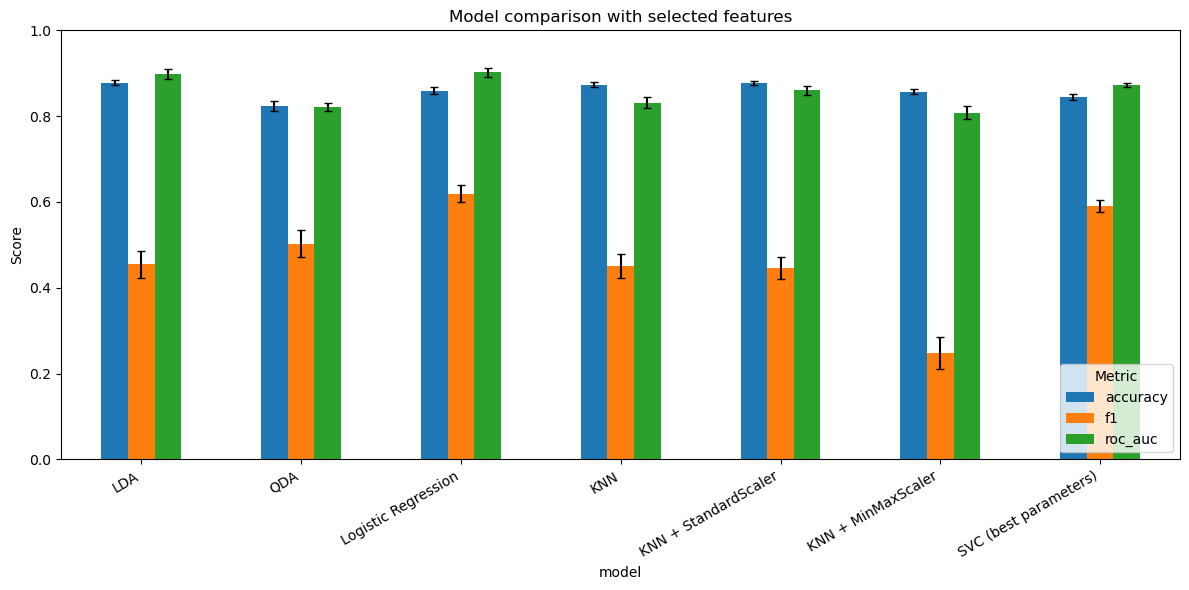

In [51]:
#now we will fit different classification model using only the selected feature:
from collections import OrderedDict

from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

# Define models

lda = LDA()
qda = QDA()

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

knn = KNeighborsClassifier(n_neighbors=11)

knn_std = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=16))
])

knn_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=17))
])

SVC_best = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        C=10,
        gamma=0.1,
        class_weight='balanced'
    ))
])

models = OrderedDict([
    ('LDA', lda),
    ('QDA', qda),
    ('Logistic Regression', log_reg),
    ('KNN', knn),
    ('KNN + StandardScaler', knn_std),
    ('KNN + MinMaxScaler', knn_minmax),
    ('SVC (best parameters)', SVC_best)
])

# Compare models (CV only)
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_list = []
for name, model in models.items():
    cv_res = cross_validate(
        model, X_selected, y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    row = {'model': name}
    for metric in scoring:
        row[metric] = cv_res[f'test_{metric}'].mean()
        row[f'{metric}_std'] = cv_res[f'test_{metric}'].std()
    results_list.append(row)

results_selected = pd.DataFrame(results_list)
results_selected

#and now we print the same graph in order to compare the different models:

results_plot_selected = results_selected.set_index('model')

# Colonne delle metriche (senza le colonne _std)
metric_cols = [c for c in results_plot_selected.columns if not c.endswith('_std')]
std_cols = [c + '_std' for c in metric_cols]

means = results_plot_selected[metric_cols]
stds = results_plot_selected[std_cols]
stds.columns = metric_cols  # rinomino per allineare gli indici con means

ax = means.plot(
    kind='bar',
    figsize=(12, 6),
    yerr=stds,
    capsize=3
)
plt.ylabel("Score")
plt.title("Model comparison with selected features")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', title='Metric')
plt.tight_layout()
plt.show()

### Best Classifer: Logistic Regression

In [52]:
X_selected = train_data[selected_features]

best_classifier = Pipeline([('scaler', StandardScaler()),
                      ('lasso', LogisticRegression(
                                solver="liblinear",   
                                max_iter=1000,
                                class_weight="balanced"))])

best_classifier.fit(X_selected, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

# 2.5 Best Classifier on Test Set

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
#now we can construct the confusion metrics and extract the test set error with a full report:
y_test = test_data['Revenue']
X_test = test_data[selected_features]

y_test_prediction = best_classifier.predict(X_test)

lr_results = {
    'Method': 'Logistic Regression (Supervised)',
    'accuracy': accuracy_score(y_test, y_test_prediction),
    'precision': precision_score(y_test, y_test_prediction),
    'recall': recall_score(y_test, y_test_prediction),
    'f1': f1_score(y_test, y_test_prediction),
    'roc_auc': roc_auc_score(y_test, y_test_prediction)
}
lr_results

{'Method': 'Logistic Regression (Supervised)',
 'accuracy': 0.8666450356911096,
 'precision': 0.5408163265306123,
 'recall': 0.7944325481798715,
 'f1': 0.6435385949696444,
 'roc_auc': np.float64(0.8369868285832436)}

In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, recall_score, precision_score,
    roc_curve, auc
)

# --- Predictions (test set, Lasso-selected features) ---
y_test_prediction = best_classifier.predict(X_test[selected_features_LASSO])
y_test_proba = best_classifier.predict_proba(X_test[selected_features_LASSO])[:, 1]

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_test_prediction)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

# --- Metrics ---
accuracy = accuracy_score(y_test, y_test_prediction)
misclass = 1 - accuracy
sensitivity = recall_score(y_test, y_test_prediction)
precision = precision_score(y_test, y_test_prediction)
specificity = tn / (tn + fp)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Misclassification rate: {misclass:.4f}")
print(f"Sensitivity (recall): {sensitivity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Specificity: {specificity:.4f}")


Confusion Matrix:
[[2300  315]
 [  96  371]]

Accuracy: 0.8666
Misclassification rate: 0.1334
Sensitivity (recall): 0.7944
Precision: 0.5408
Specificity: 0.8795


Text(0.5, 1.0, 'Confusion Matrix')

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix (%)')

Text(0.5, 25.722222222222214, 'Predicted label')

Text(688.0751633986929, 0.5, 'True label')

Text(0.5, 25.722222222222214, 'False Positive Rate')

Text(1172.3031045751634, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'ROC Curve')

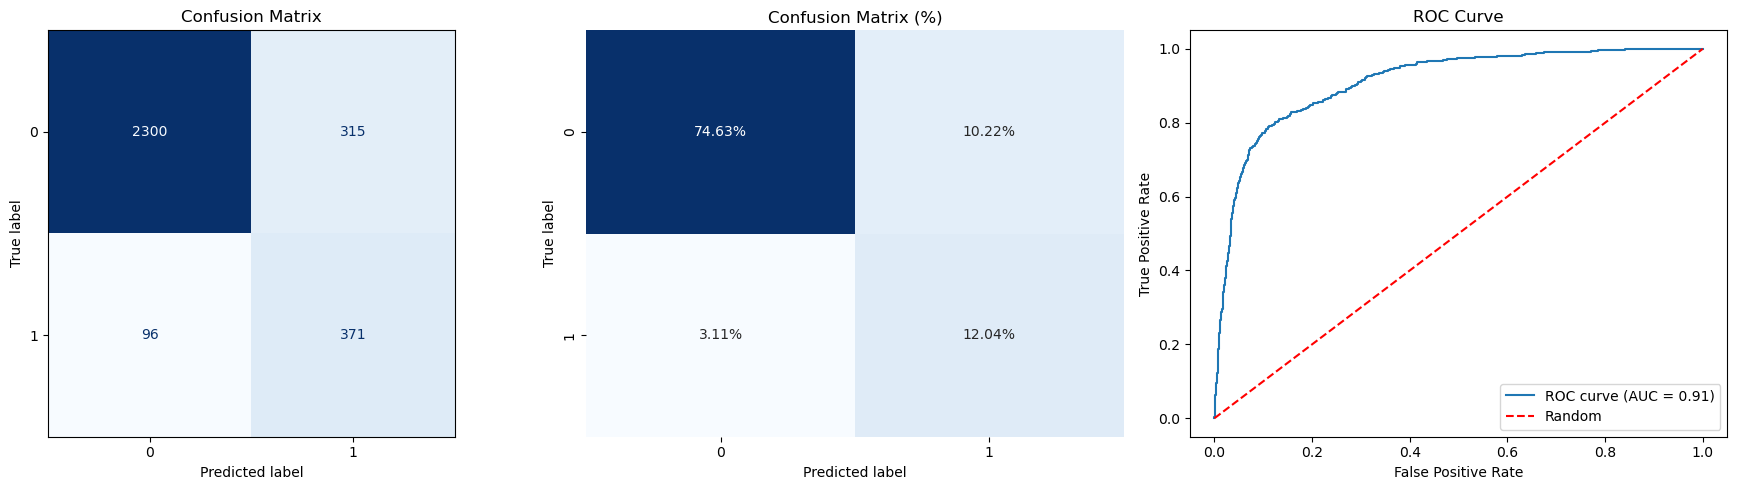

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)
# --- All three plots in one row ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix (counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# 2. Confusion matrix (percentages)
sns.heatmap(cm / np.sum(cm), annot=True, fmt='.2%', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title("Confusion Matrix (%)")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

# 3. ROC curve
axes[2].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

Our final model (Logistic Regression, Lasso-selected features) achieves **86.7% accuracy** on the test set, 
correctly classifying the large majority of both buyers and non-buyers. However, given the ~85/15 class 
imbalance in Revenue, accuracy alone is not sufficient to judge performance — the other metrics tell a more 
complete story:

- **Sensitivity (Recall) = 0.794**: the model correctly identifies about 79% of actual buyers (371 out of 
  467 total buyers, i.e. 371 + 96 false negatives). This means roughly 1 in 5 real buyers are missed 
  (96 false negatives) — a meaningful limitation if the business goal is to catch as many potential 
  purchasers as possible (e.g., for targeted marketing interventions).
- **Precision = 0.542**: of all the samples the model flags as "will purchase," only about 54% actually do. 
  The remaining ~46% (314 false positives) are non-buyers incorrectly flagged as likely buyers.
- **Specificity = 0.880**: the model is quite good at correctly identifying non-buyers (88% of true 
  non-buyers are correctly classified), which is expected given they make up the majority class.

**Trade-off summary**: the model prioritizes recall over precision relative to a naive baseline, likely a 
consequence of using `class_weight='balanced'`, which penalizes misclassifying the minority (buyer) class 
more heavily. This is a reasonable choice for this business context: failing to identify a genuine potential 
buyer (false negative) is arguably more costly than mistakenly flagging a non-buyer as a lead (false 
positive), since the latter simply results in a wasted marketing touchpoint rather than a missed sale.

# Classification excluding ``ExitRates``

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

,model,accuracy,accuracy_std,f1,f1_std,roc_auc,roc_auc_std
0,LDA,0.875540,0.004797,0.444602,0.024626,0.898145,0.012293
1,QDA,0.820932,0.011278,0.466035,0.023631,0.813521,0.005952
2,Logistic Regression,0.859645,0.009049,0.618749,0.023408,0.902426,0.010709
3,KNN,0.873270,0.004800,0.449785,0.027542,0.831787,0.014882
4,KNN + StandardScaler,0.882245,0.004938,0.490577,0.026196,0.867927,0.011579
5,KNN + MinMaxScaler,0.865484,0.006051,0.354157,0.027582,0.837852,0.013429
6,SVC (best parameters),0.851319,0.005876,0.606822,0.010000,0.872857,0.004465


Text(0, 0.5, 'Score')

Text(0.5, 1.0, "Model comparison not including the 'Exit Rate' variable")

(0.0, 1.0)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'LDA'),
  Text(1, 0, 'QDA'),
  Text(2, 0, 'Logistic Regression'),
  Text(3, 0, 'KNN'),
  Text(4, 0, 'KNN + StandardScaler'),
  Text(5, 0, 'KNN + MinMaxScaler'),
  Text(6, 0, 'SVC (best parameters)')])

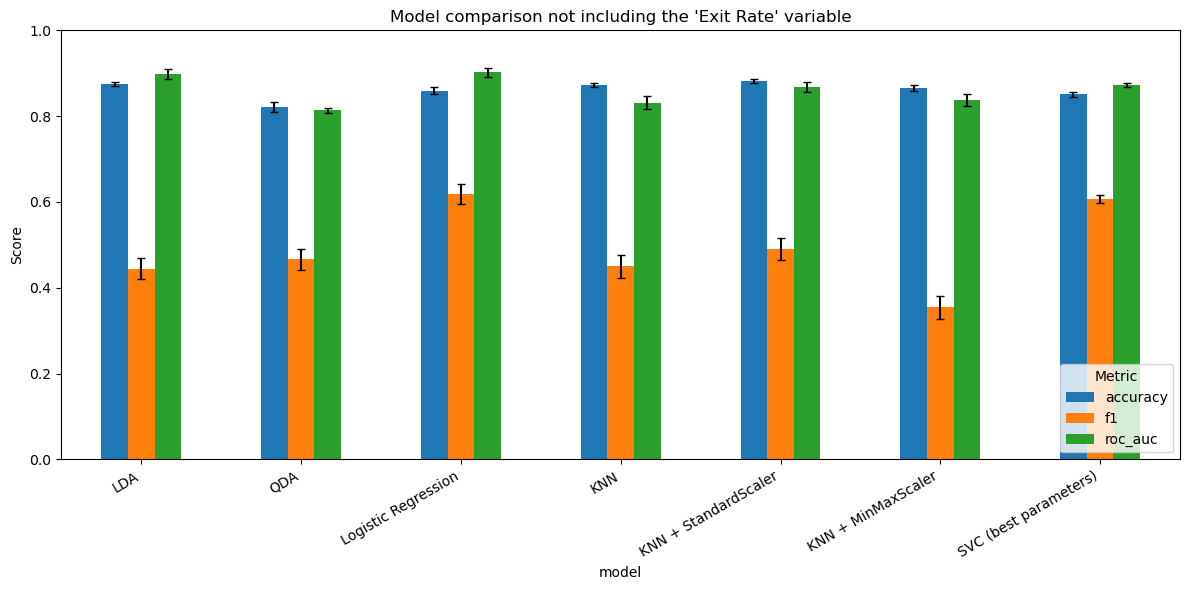

In [61]:
#recomputing the performance without the 'Exit Rate' feature in order to see if it adds something useful to the model: 

#redefinition of X_selected 
selected_feature_NOExitRates= ['Administrative','Informational','ProductRelated','ProductRelated_Duration','PageValues','month_sin','month_cos' 
                           ,'Region_9', 'TrafficType_2', 'TrafficType_3', 'TrafficType_8','TrafficType_10','TrafficType_11','TrafficType_13', 'TrafficType_20']

X_selected = train_data[selected_feature_NOExitRates]

# Define models

lda = LDA()
qda = QDA()

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

knn = KNeighborsClassifier(n_neighbors=11)

knn_std = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=16))
])

knn_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=17))
])

SVC_best = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        C=10,
        gamma=0.1,
        class_weight='balanced'
    ))
])

models = OrderedDict([
    ('LDA', lda),
    ('QDA', qda),
    ('Logistic Regression', log_reg),
    ('KNN', knn),
    ('KNN + StandardScaler', knn_std),
    ('KNN + MinMaxScaler', knn_minmax),
    ('SVC (best parameters)', SVC_best)
])

# Compare models (CV only)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_list = []
for name, model in models.items():
    cv_res = cross_validate(
        model, X_selected, y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    row = {'model': name}
    for metric in scoring:
        row[metric] = cv_res[f'test_{metric}'].mean()
        row[f'{metric}_std'] = cv_res[f'test_{metric}'].std()
    results_list.append(row)

results_Noexitrates = pd.DataFrame(results_list)
results_Noexitrates

#and now we print the same graph in order to compare the different models:

results_plot_Noexitrates = results_Noexitrates.set_index('model')

# Colonne delle metriche (senza le colonne _std)
metric_cols = [c for c in results_plot_Noexitrates.columns if not c.endswith('_std')]
std_cols = [c + '_std' for c in metric_cols]

means = results_plot_Noexitrates[metric_cols]
stds = results_plot_Noexitrates[std_cols]
stds.columns = metric_cols  # rinomino per allineare gli indici con means

ax = means.plot(
    kind='bar',
    figsize=(12, 6),
    yerr=stds,
    capsize=3
)
plt.ylabel("Score")
plt.title("Model comparison not including the 'Exit Rate' variable")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', title='Metric')
plt.tight_layout()
plt.show()

We obtain a little different in the results but at the end the best model is always the logistic regression (almost with the same value) so we would say that the Exit Rates do not make such difference in the model prediction in order to correctly classify the model.
We will stay with the first model that include the 'Exit Rate' variable and test on the test set to obtain a plausible test error:

---
---
---

# Task 3 
_Repeat the analysis done at step 2 with clustering-based algorithms; compare the performance with respect to the best classification model_

As we did for the classification task we will fit diffent algorithm for clustering keeping in mind that our goal is to obtain 2 cluster as the two ``Revenue`` binary value and then we procedee with the comparison of the models.

## Dimensionality Reduction

In [62]:
#we will fit different clustering algorithm so in order to compute distance between points and be coherent with the datatype of that point we will first divide our dataset 
#into two datatypes as numerical and categorical

numerical_cols = [
    'Administrative', 'Administrative_Duration', 'Informational',
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
    'month_sin', 'month_cos'
]

categorical_cols = [
    'Weekend', 'VisitorType_Other', 'VisitorType_Returning_Visitor',
    'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6',
    'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13',
    'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6',
    'Region_7', 'Region_8', 'Region_9',
    'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5',
    'TrafficType_6', 'TrafficType_7', 'TrafficType_8', 'TrafficType_9',
    'TrafficType_10', 'TrafficType_11', 'TrafficType_12', 'TrafficType_13',
    'TrafficType_14', 'TrafficType_15', 'TrafficType_16', 'TrafficType_17',
    'TrafficType_18', 'TrafficType_19', 'TrafficType_20',
    'OperatingSystems_2', 'OperatingSystems_3', 'OperatingSystems_4',
    'OperatingSystems_5', 'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8'
]
y = train_data['Revenue'].astype(int)  # we will 'predict' the Revenue as in the classification case

PCA was not applied to the categorical variables because it relies on variance and linear combinations, which are meaningful only for continuous numerical data, not for nominal categories. It was therefore applied only to the numerical features, while Hamming distance was used to handle the categorical ones appropriately

## Numerical PCA

PCA()

<Figure size 800x500 with 0 Axes>

Text(0.5, 0, 'Number of Components')

Text(0, 0.5, 'Cumulative Explained Variance')

Text(0.5, 1.0, 'Cumulative Explained Variance by Number of Components')

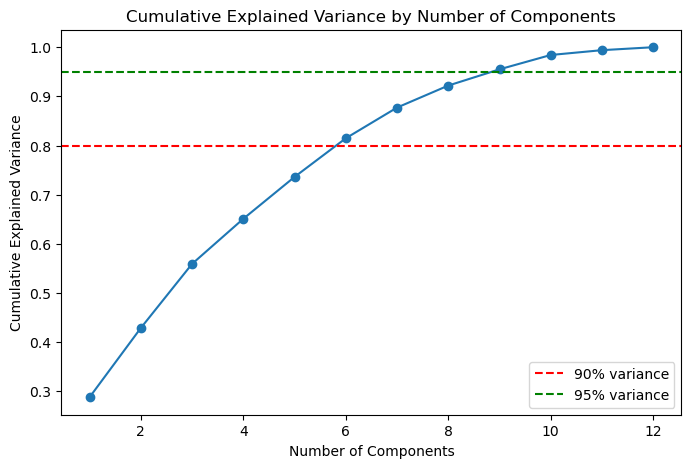

In [63]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

#selection only the numerical feature to apply PCA
X_NUM = train_data[numerical_cols]
# scaling before apply PCA (it's sensitive to it)
scaler = StandardScaler()
X_train_scaled_NUM = scaler.fit_transform(X_NUM)

# Fit PCA with no component limit, just to inspect variance
pca_NUM = PCA()
pca_NUM.fit(X_train_scaled_NUM)

cumulative_var = np.cumsum(pca_NUM.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.title('Cumulative Explained Variance by Number of Components')
plt.show()

In [64]:
#given the plot we will select the number of PC that explain a resonably sourse of variability, in this case 6 (explain at least 80%)
# 1. Initialize PCA with your chosen 6 components
pca_6 = PCA(n_components=6, random_state=42)

# 2. Transform your scaled numerical data into the 6 components
# This creates a NumPy array of shape (number of rows, 6)
X_NUMpca_array = pca_6.fit_transform(X_train_scaled_NUM)

# 3. Convert it into a clean Pandas DataFrame with explicit column names
pc_columns = [f"PC{i+1}" for i in range(6)]
X_pca_NUMfinal = pd.DataFrame(X_NUMpca_array, columns=pc_columns)


for visual rapresentation of the clustering that we could obtain we used different dimensionality reduction apply to the 6 PCs chosen before, this will further reduce the dimensionality in order to find to dimension for which the distance beetween points will be more or less the same compared to the pca space

## UMAP

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 1000x700 with 0 Axes>

Text(0.5, 0, 'UMAP 1')

Text(0, 0.5, 'UMAP 2')

Text(0.5, 1.0, 'UMAP PCs=6')

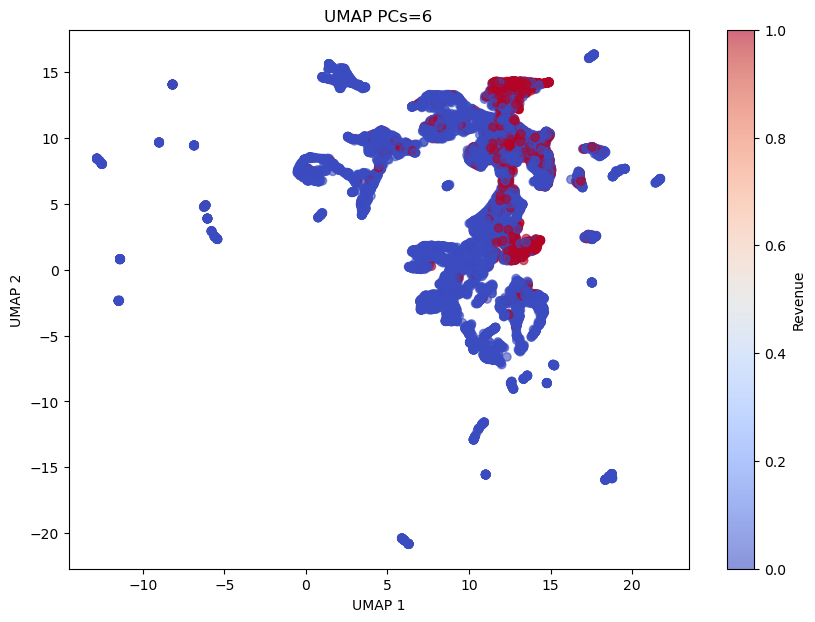

In [65]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_NUMpca_array)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.colorbar(label='Revenue')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP PCs=6')
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 0, 'UMAP 1')

Text(0.5, 0.5, 'UMAP 2')

Text(0.5, 0, 'UMAP 3')

Text(0.5, 0.92, 'UMAP 3D PCs=6')

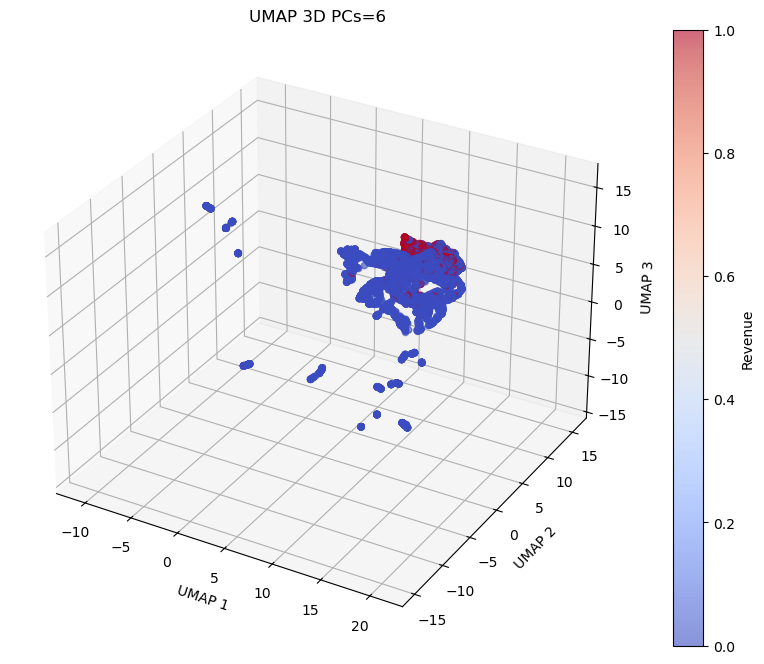

In [66]:
import umap
from mpl_toolkits.mplot3d import Axes3D

# Step 2: UMAP riduce a 3 componenti
reducer = umap.UMAP(n_components=3, random_state=42)
X_umap3d = reducer.fit_transform(X_NUMpca_array)

# Step 3: scatter plot 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_umap3d[:, 0], X_umap3d[:, 1], X_umap3d[:, 2],
                 c=y, cmap='coolwarm', alpha=0.6)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.set_title('UMAP 3D PCs=6')

fig.colorbar(sc, ax=ax, label='Revenue')
plt.show()

## t-SNE

<Figure size 1000x700 with 0 Axes>

Text(0.5, 0, 't-SNE 1')

Text(0, 0.5, 't-SNE 2')

Text(0.5, 1.0, 't-SNE 2D PCs=6')

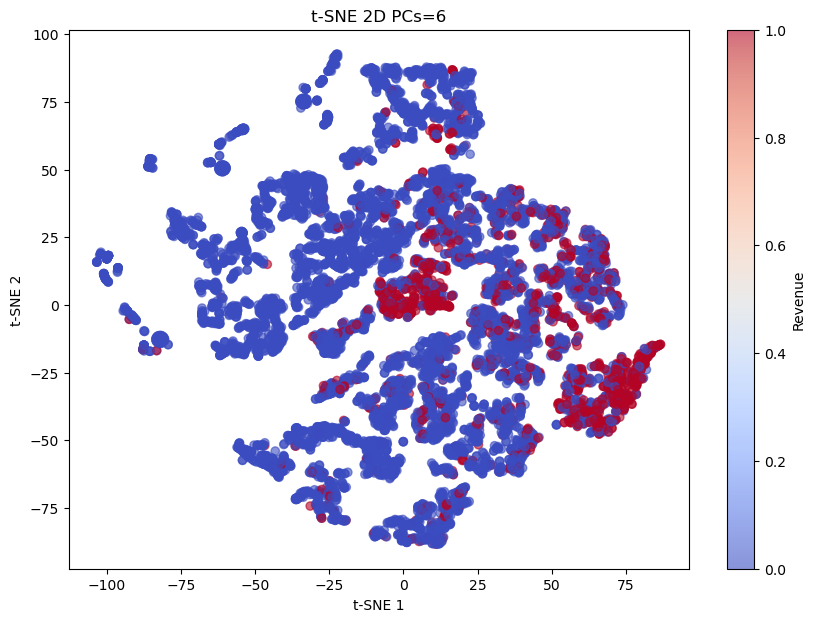

In [67]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne2d = tsne.fit_transform(X_NUMpca_array)

# Plot
plt.figure(figsize=(10, 7))
sc = plt.scatter(X_tsne2d[:, 0], X_tsne2d[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.colorbar(sc, label='Revenue')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE 2D PCs=6')
plt.show()

Text(0.5, 0, 't-SNE 1')

Text(0.5, 0.5, 't-SNE 2')

Text(0.5, 0, 't-SNE 3')

Text(0.5, 0.92, 't-SNE 3D su PCs=6')

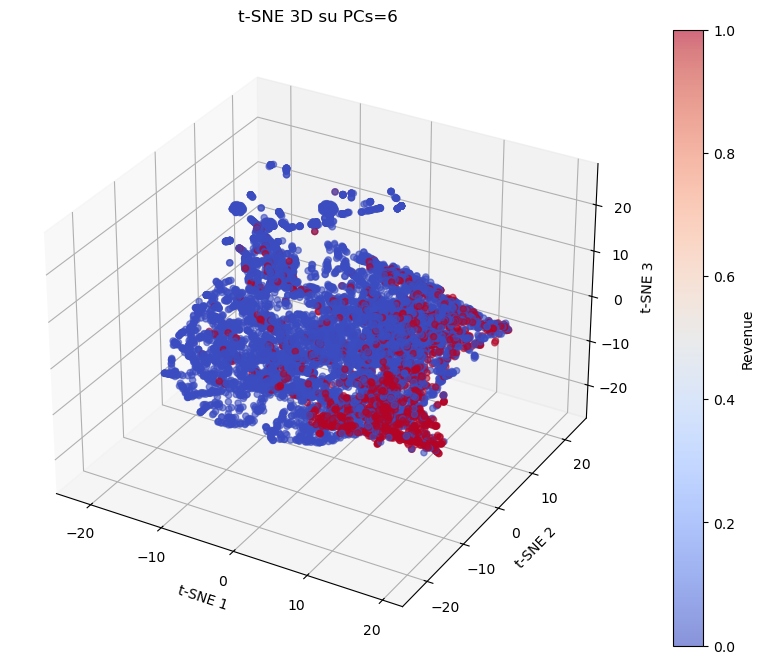

In [68]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

tsne = TSNE(n_components=3, random_state=42, perplexity=30)
X_tsne3d = tsne.fit_transform(X_NUMpca_array)

# Step 3: scatter plot 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_tsne3d[:, 0], X_tsne3d[:, 1], X_tsne3d[:, 2],
                 c=y, cmap='coolwarm', alpha=0.6)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.set_title('t-SNE 3D su PCs=6')

fig.colorbar(sc, ax=ax, label='Revenue')
plt.show()

as we can notice there is no a clear separation in the two clusters given the two dimension found by UMAP and t-SNE, but this could be due only to the fact that we are further reducing the dimensionality. So could be that in the pca space the points will be clearly split according to the numerical or categorical feature. 

---
---

# Clustering

### Metrics used for evaluation

In [69]:
#this will be the metrics definition for all the clustering that we are chosen, we will not use all the metrics at the end given that we have the label to predict so we will stay at
#the end with the external metrics comparison between algorithm.

import numpy as np
import pandas as pd
from sklearn.metrics import (
    jaccard_score, adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)


def compute_recall(cluster_labels, true_labels, cluster_index, class_label):
    cluster_indices = np.where(cluster_labels == cluster_index)[0]
    class_indices = np.where(true_labels == class_label)[0]
    nkj = len(np.intersect1d(cluster_indices, class_indices))
    nj = len(class_indices)
    return nkj / nj if nj > 0 else 0.0


def compute_precision(cluster_labels, true_labels, cluster_index, class_label):
    cluster_indices = np.where(cluster_labels == cluster_index)[0]
    class_indices = np.where(true_labels == class_label)[0]
    nkj = len(np.intersect1d(cluster_indices, class_indices))
    nk = len(cluster_indices)
    return nkj / nk if nk > 0 else 0.0


def evaluate_clustering(pred_labels, y, name="Model", X=None):
    """
    Evaluates a binary (2-cluster) clustering against a binary target.
    Aligns cluster labels with class labels to avoid arbitrary 0/1 swap penalties.
    If X is provided, also computes internal clustering-quality metrics.
    """
    y = np.asarray(y)
    pred_labels = np.asarray(pred_labels)

    n_cluster_0 = int(np.sum(pred_labels == 0))
    n_cluster_1 = int(np.sum(pred_labels == 1))

    # --- Align cluster labels with y (pick whichever mapping maximizes accuracy) ---
    acc_direct = np.mean(pred_labels == y)
    acc_swapped = np.mean((1 - pred_labels) == y)
    swapped = acc_swapped > acc_direct
    pred_aligned = (1 - pred_labels) if swapped else pred_labels
    acc = max(acc_direct, acc_swapped)

    # --- Per-cluster recall / precision (external, uses true labels) ---
    recall_0_0 = compute_recall(pred_aligned, y, 0, 0)
    recall_0_1 = compute_recall(pred_aligned, y, 0, 1)
    recall_1_0 = compute_recall(pred_aligned, y, 1, 0)
    recall_1_1 = compute_recall(pred_aligned, y, 1, 1)

    precision_0_0 = compute_precision(pred_aligned, y, 0, 0)
    precision_0_1 = compute_precision(pred_aligned, y, 0, 1)
    precision_1_0 = compute_precision(pred_aligned, y, 1, 0)
    precision_1_1 = compute_precision(pred_aligned, y, 1, 1)

    purity_0 = max(precision_0_0, precision_0_1)
    purity_1 = max(precision_1_1, precision_1_0)

    # --- External metrics (agreement with true labels) ---
    jaccard = jaccard_score(y, pred_aligned)
    ari = adjusted_rand_score(y, pred_labels)          # ARI/NMI are label-invariant, no need for alignment
    nmi = normalized_mutual_info_score(y, pred_labels)

    # --- Internal metrics (cluster quality, no labels needed) ---
    if X is not None:
        silhouette = silhouette_score(X, pred_labels)
        davies_bouldin = davies_bouldin_score(X, pred_labels)
        calinski_harabasz = calinski_harabasz_score(X, pred_labels)
    else:
        silhouette = davies_bouldin = calinski_harabasz = np.nan

    print(f"--- {name} ---")
    print(f"Cluster sizes: cluster 0 = {n_cluster_0}, cluster 1 = {n_cluster_1}")
    print(f"Accuracy (aligned): {acc:.4f}  {'(labels swapped)' if swapped else ''}")
    print(f"Purity: cluster 0 = {purity_0:.4f}, cluster 1 = {purity_1:.4f}")
    print(f"Jaccard: {jaccard:.4f} | ARI: {ari:.4f} | NMI: {nmi:.4f}")
    if X is not None:
        print(f"Silhouette: {silhouette:.4f} | Davies-Bouldin: {davies_bouldin:.4f} | Calinski-Harabasz: {calinski_harabasz:.2f}")
    print()

    return {
        'Method': name,
        'n_cluster_0': n_cluster_0,
        'n_cluster_1': n_cluster_1,
        'accuracy': acc,
        'recall_0_0': recall_0_0, 'recall_0_1': recall_0_1,
        'recall_1_0': recall_1_0, 'recall_1_1': recall_1_1,
        'precision_0_0': precision_0_0, 'precision_0_1': precision_0_1,
        'precision_1_0': precision_1_0, 'precision_1_1': precision_1_1,
        'purity_0': purity_0, 'purity_1': purity_1,
        'jaccard': jaccard,
        'ari': ari,
        'nmi': nmi,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski_harabasz,
    }

## 1. K-means

we fitted a K-means algorithm only to numerical variabled scaled and then with PCA, we didn't consider categorical variables at all given that computing a mean for that variable would be impossibile (and reasonably do not make sense)

### All numerical

In [70]:
from sklearn.cluster import KMeans

#given that before we already computed a scaled version for the numerical one we will proced to fit a K-means with that feature 
#also we will use only 2 numer of cluster given that the revenue is a binary variable (0/1)
kmeans_NUM = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init="auto")
kmeans_NUM.fit(X_train_scaled_NUM)
pred_labels_NUM = kmeans_NUM.labels_

results_kmeans_NUM = evaluate_clustering(pred_labels_NUM, y, name="KMeans (Numerical, Scaled)", X=X_train_scaled_NUM)

KMeans(n_clusters=2, random_state=42)

--- KMeans (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 4388, cluster 1 = 4860
Accuracy (aligned): 0.5630  
Purity: cluster 0 = 0.9291, cluster 1 = 0.7675
Jaccard: 0.2185 | ARI: 0.0146 | NMI: 0.0467
Silhouette: 0.1734 | Davies-Bouldin: 2.0595 | Calinski-Harabasz: 1571.79



### Numerical + PCA

No need to scale since X_num already scaled. se facciamo pca senza scegliere i componenti è come se avessimo tutte le features ma lungo tutti i PCs. 

In [71]:
# 1. Initialize K-Means 
# We'll use 2 clusters since that was in your original code
kmeans_NUM_PCA = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init="auto")

# 2. Fit the model AND get the cluster labels all in one step
# We pass our 6-component DataFrame here
pred_labels_NUM_PCA_kmeans = kmeans_NUM_PCA.fit_predict(X_pca_NUMfinal)

results_kmeans_NUM_PCA = evaluate_clustering(
    pred_labels_NUM_PCA_kmeans, 
    y, 
    name="KMeans (6 PCA Components)", X=X_pca_NUMfinal
)
print(results_kmeans_NUM_PCA)

--- KMeans (6 PCA Components) ---
Cluster sizes: cluster 0 = 4290, cluster 1 = 4958
Accuracy (aligned): 0.5604  
Purity: cluster 0 = 0.9361, cluster 1 = 0.7646
Jaccard: 0.2231 | ARI: 0.0121 | NMI: 0.0533
Silhouette: 0.2045 | Davies-Bouldin: 1.7726 | Calinski-Harabasz: 1960.84

{'Method': 'KMeans (6 PCA Components)', 'n_cluster_0': 4290, 'n_cluster_1': 4958, 'accuracy': np.float64(0.5604455017301038), 'recall_0_0': 0.5144101447418983, 'recall_0_1': 0.19014573213046496, 'recall_1_0': 0.4855898552581017, 'recall_1_1': 0.8098542678695351, 'precision_0_0': 0.9361305361305361, 'precision_0_1': 0.06386946386946386, 'precision_1_0': 0.7646228317870108, 'precision_1_1': 0.2353771682129891, 'purity_0': 0.9361305361305361, 'purity_1': 0.7646228317870108, 'jaccard': np.float64(0.22305045871559634), 'ari': 0.012116408093444088, 'nmi': np.float64(0.05332801040872056), 'silhouette': np.float64(0.20450705026389462), 'davies_bouldin': np.float64(1.7726443382557753), 'calinski_harabasz': np.float64(1960

## 2. K-Medoids

### All numerical

In [72]:
from sklearn_extra.cluster import KMedoids

kmedoids_NUM = KMedoids(n_clusters=2, metric='euclidean', init='k-medoids++', random_state=42)
kmedoids_NUM.fit(X_train_scaled_NUM)
pred_labels_NUM_medoids = kmedoids_NUM.labels_

results_kmedoids_NUM = evaluate_clustering(pred_labels_NUM_medoids, y, name="KMedoids (Numerical, Scaled)", X=X_train_scaled_NUM)

ModuleNotFoundError: No module named 'sklearn_extra'

In [ ]:
"""from skitlearn_extra import Kmedoids
import numpy as np
from sklearn.metrics import pairwise_distances

# 1. Calculate the distance matrix first
# KMedoids in this package requires a distance matrix input
dist_matrix = pairwise_distances(X_numerical_scaled, metric='euclidean')

# 2. Fit the model using FasterPAM
# FasterPAM is the recommended, efficient implementation
result = kmedoids.fasterpam(dist_matrix, 2)

pred_labels_NUM_medoids = result.labels

# 4. Evaluate using your existing function
results_kmedoids_NUM = evaluate_clustering(pred_labels_NUM_medoids, y, name="KMedoids (Numerical, Scaled)", X=X_numerical_scaled)"""

'from skitlearn_extra import Kmedoids\nimport numpy as np\nfrom sklearn.metrics import pairwise_distances\n\n# 1. Calculate the distance matrix first\n# KMedoids in this package requires a distance matrix input\ndist_matrix = pairwise_distances(X_numerical_scaled, metric=\'euclidean\')\n\n# 2. Fit the model using FasterPAM\n# FasterPAM is the recommended, efficient implementation\nresult = kmedoids.fasterpam(dist_matrix, 2)\n\npred_labels_NUM_medoids = result.labels\n\n# 4. Evaluate using your existing function\nresults_kmedoids_NUM = evaluate_clustering(pred_labels_NUM_medoids, y, name="KMedoids (Numerical, Scaled)", X=X_numerical_scaled)'

### Categorical

In [ ]:
#for the cateogrical in order to use the hamming distance we will not use the dummy variable present in our dataset but we apply a label encoder in order to make sense to compute an 
#hamming distance given our dummy variables:
from sklearn.preprocessing import LabelEncoder

train_cat_encoded = train_data[categorical_cols].apply(lambda col: LabelEncoder().fit_transform(col))


kmedoids_CAT = KMedoids(n_clusters=2, metric='hamming', init='k-medoids++', random_state=42)
kmedoids_CAT.fit(train_cat_encoded )
pred_labels_CAT_medoids = kmedoids_NUM.labels_

results_kmedoids_CAT = evaluate_clustering(pred_labels_CAT_medoids, y, name="KMedoids (Numerical, Scaled)", X=train_cat_encoded )

KMedoids(init='k-medoids++', metric='hamming', n_clusters=2, random_state=42)

--- KMedoids (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 4581, cluster 1 = 4667
Accuracy (aligned): 0.5608  
Purity: cluster 0 = 0.9088, cluster 1 = 0.7808
Jaccard: 0.2012 | ARI: 0.0147 | NMI: 0.0284
Silhouette: 0.0075 | Davies-Bouldin: 11.9838 | Calinski-Harabasz: 62.17



In [ ]:
"""# 1. Calculate the distance matrix first
# KMedoids in this package requires a distance matrix input
dist_matrix = pairwise_distances(X_categorical_encoded, metric='euclidean')

# 2. Fit the model using FasterPAM
# FasterPAM is the recommended, efficient implementation
result = kmedoids.fasterpam(dist_matrix, 2)

pred_labels_CAT_medoids = result.labels

# 4. Evaluate using your existing function
results_kmedoids_CAT = evaluate_clustering(pred_labels_CAT_medoids, y, name="KMedoids (Numerical, Scaled)", X=X_categorical_encoded)"""

'# 1. Calculate the distance matrix first\n# KMedoids in this package requires a distance matrix input\ndist_matrix = pairwise_distances(X_categorical_encoded, metric=\'euclidean\')\n\n# 2. Fit the model using FasterPAM\n# FasterPAM is the recommended, efficient implementation\nresult = kmedoids.fasterpam(dist_matrix, 2)\n\npred_labels_CAT_medoids = result.labels\n\n# 4. Evaluate using your existing function\nresults_kmedoids_CAT = evaluate_clustering(pred_labels_CAT_medoids, y, name="KMedoids (Numerical, Scaled)", X=X_categorical_encoded)'

### Numerical + PCA

In [ ]:
kmedoids_NUM = KMedoids(n_clusters=2, metric='euclidean', init='k-medoids++', random_state=42)
kmedoids_NUM.fit(X_pca_NUMfinal)
pred_labels_NUM_PCAmedoids= kmedoids_NUM.labels_

results_kmedoids_NUM_PCA = evaluate_clustering(pred_labels_NUM_PCAmedoids, y, name="KMedoids (Numerical, Scaled)", X=X_pca_NUMfinal)

KMedoids(init='k-medoids++', n_clusters=2, random_state=42)

--- KMedoids (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 4581, cluster 1 = 4667
Accuracy (aligned): 0.5608  
Purity: cluster 0 = 0.9088, cluster 1 = 0.7808
Jaccard: 0.2012 | ARI: 0.0147 | NMI: 0.0284
Silhouette: 0.2293 | Davies-Bouldin: 1.8390 | Calinski-Harabasz: 1773.53



In [ ]:
"""# 1. Calculate the distance matrix first
# KMedoids in this package requires a distance matrix input
dist_matrix = pairwise_distances(X_pca_NUMfinal, metric='euclidean')

# 2. Fit the model using FasterPAM
# FasterPAM is the recommended, efficient implementation
result = kmedoids.fasterpam(dist_matrix, 2)

pred_labels_NUM_PCAmedoids = result.labels

# 4. Evaluate using your existing function
results_kmedoids_NUM_PCA = evaluate_clustering(pred_labels_NUM_PCAmedoids, y, name="KMedoids (Numerical, Scaled)", X=X_pca_NUMfinal)"""

'# 1. Calculate the distance matrix first\n# KMedoids in this package requires a distance matrix input\ndist_matrix = pairwise_distances(X_pca_NUMfinal, metric=\'euclidean\')\n\n# 2. Fit the model using FasterPAM\n# FasterPAM is the recommended, efficient implementation\nresult = kmedoids.fasterpam(dist_matrix, 2)\n\npred_labels_NUM_PCAmedoids = result.labels\n\n# 4. Evaluate using your existing function\nresults_kmedoids_NUM_PCA = evaluate_clustering(pred_labels_NUM_PCAmedoids, y, name="KMedoids (Numerical, Scaled)", X=X_pca_NUMfinal)'

## Hierarchical

We chose as metric 'average' since 'ward' tends to create compact and evenly sized round clusters. Complete linkage merges based on the average distance.

In [ ]:
#importing the model and definition of the function used to plot the dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

distance_threshold=None#270

def plot_dendrogram(Z=None, model=None, X=None, **kwargs):
    annotate_above = kwargs.pop('annotate_above', 0)

    # Reconstruct the linakge matrix if the standard model API was used
    if Z is None:
        if hasattr(model, 'distances_') and model.distances_ is not None:
            # create the counts of samples under each node
            counts = np.zeros(model.children_.shape[0])
            n_samples = len(model.labels_)
            for i, merge in enumerate(model.children_):
                current_count = 0
                for child_idx in merge:
                    if child_idx < n_samples:
                        current_count += 1  # leaf node
                    else:
                        current_count += counts[child_idx - n_samples]
                counts[i] = current_count

            Z = np.column_stack([model.children_, model.distances_,
                                              counts]).astype(float)
        else:
            Z = linkage(X, method=model.linkage, metric=model.metric)
    
    if 'n_clusters' in kwargs:
        n_clusters = kwargs.pop('n_clusters')
        # Set the cut point just above the last but 'n_clusters' merge
        kwargs['color_threshold'] = Z[-n_clusters, 2] + 1e-6
    
    fig = plt.figure(figsize=(20,10))
    ax = fig.add_subplot(111)
    # Plot the corresponding dendrogram
    ddata = dendrogram(Z, ax=ax, **kwargs) 
    
    # Annotate nodes in the dendrogram
    for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
        x = 0.5 * sum(i[1:3])
        y = d[1]
        nid = np.where(Z[:,2] == y)[0][0]
        if y > annotate_above:
            plt.plot(x, y, 'o', c=c)
            plt.annotate(str(nid-Z.shape[0]), (x, y), xytext=(0, -5),
                         textcoords='offset points',
                         va='top', ha='center')
    if kwargs['color_threshold']:
        plt.axhline(y=kwargs['color_threshold'], c='k')
    
    return fig, ax

### All numerical

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='average')
pred_labels_NUM = hierarchical_cluster.fit_predict(X_NUM) #used only the numerical one and not the scaled

results_hierarchical_NUM = evaluate_clustering(pred_labels_NUM, y, name="KMeans (Numerical, Scaled)", X=X_NUM)

--- KMeans (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 44, cluster 1 = 9204
Accuracy (aligned): 0.8433  (labels swapped)
Purity: cluster 0 = 0.8454, cluster 1 = 0.5909
Jaccard: 0.0123 | ARI: 0.0123 | NMI: 0.0038
Silhouette: 0.8851 | Davies-Bouldin: 0.2843 | Calinski-Harabasz: 3538.06



(<Figure size 2000x1000 with 1 Axes>, <Axes: >)

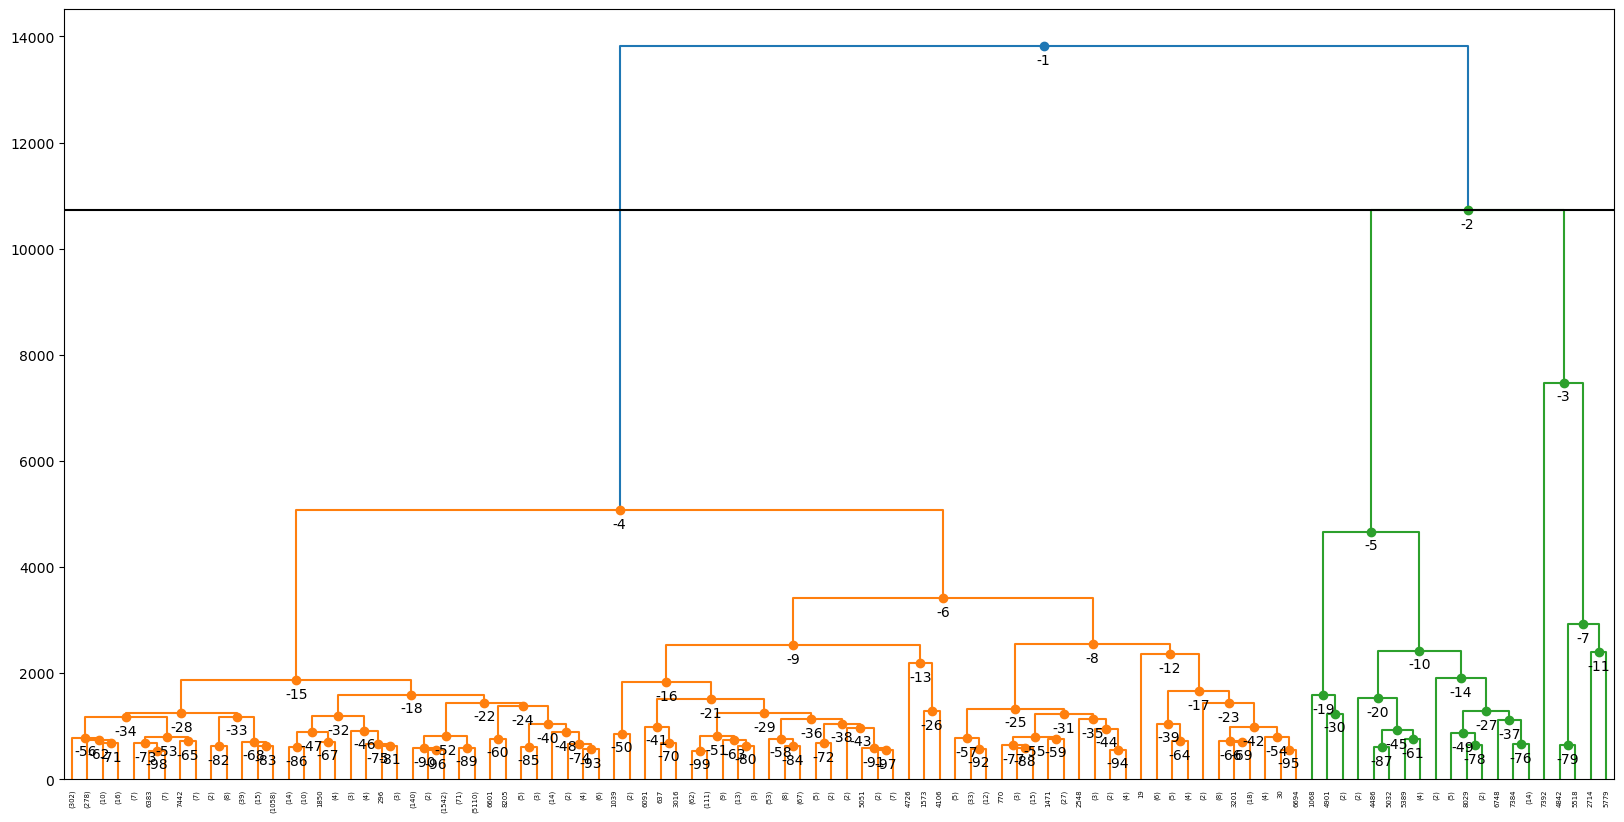

In [ ]:

plot_dendrogram(model=hierarchical_cluster, X=X_NUM, truncate_mode='lastp', p=100, 
                n_clusters=2, 
                color_threshold=distance_threshold)

plt.show()

### Categorical

In [ ]:
agg_CAT = AgglomerativeClustering(n_clusters=2, metric='hamming', linkage='average')
pred_labels_CAT_agg = agg_CAT.fit_predict(train_cat_encoded)

results_hierarchical_CAT = evaluate_clustering(pred_labels_CAT_agg, y, name="Agglomerative (Categorical, Hamming)", X=train_cat_encoded)

--- Agglomerative (Categorical, Hamming) ---
Cluster sizes: cluster 0 = 9205, cluster 1 = 43
Accuracy (aligned): 0.8421  
Purity: cluster 0 = 0.8448, cluster 1 = 0.7209
Jaccard: 0.0082 | ARI: 0.0059 | NMI: 0.0010
Silhouette: 0.2724 | Davies-Bouldin: 0.9122 | Calinski-Harabasz: 100.83



(<Figure size 2000x1000 with 1 Axes>, <Axes: >)

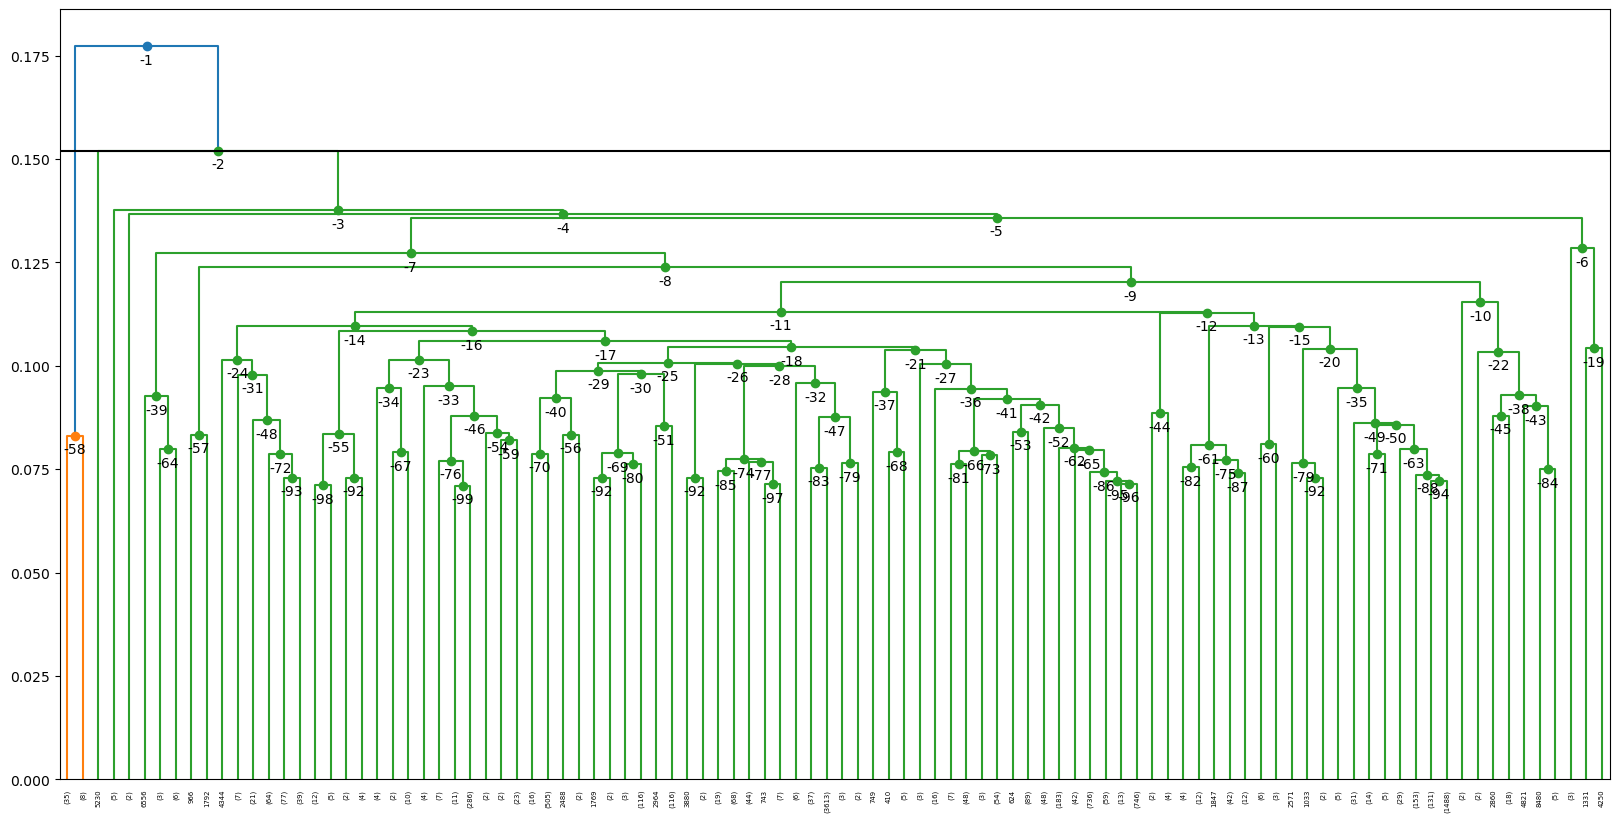

In [ ]:
plot_dendrogram(model=agg_CAT, X=train_data[categorical_cols], truncate_mode='lastp', p=100, 
                n_clusters=2, 
                color_threshold=distance_threshold)

plt.show()

### NUM+PCA

In [ ]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='average')
pred_labels_NUM_PCA_hierchical = hierarchical_cluster.fit_predict(X_pca_NUMfinal)

results_hierarchical_NUM_PCA = evaluate_clustering(pred_labels_NUM_PCA_hierchical, y, name="KMeans (Numerical, PCA)", X=X_pca_NUMfinal)

--- KMeans (Numerical, PCA) ---
Cluster sizes: cluster 0 = 3, cluster 1 = 9245
Accuracy (aligned): 0.8439  (labels swapped)
Purity: cluster 0 = 0.8441, cluster 1 = 1.0000
Jaccard: 0.0000 | ARI: -0.0005 | NMI: 0.0003
Silhouette: 0.8267 | Davies-Bouldin: 0.4566 | Calinski-Harabasz: 137.28



(<Figure size 2000x1000 with 1 Axes>, <Axes: >)

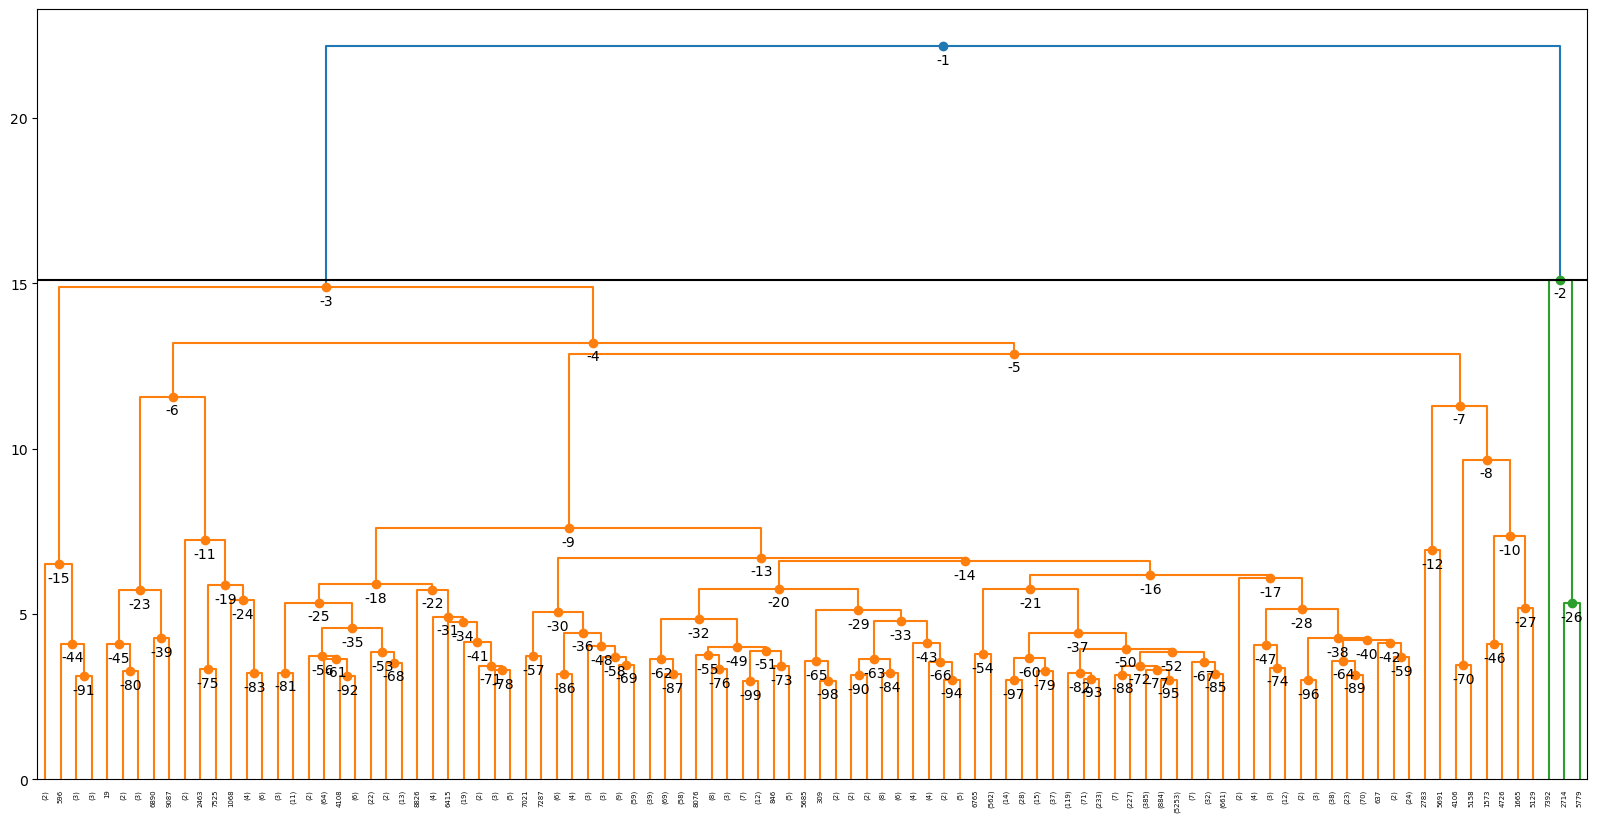

In [ ]:
plot_dendrogram(model=hierarchical_cluster, X=X_NUMpca_array, truncate_mode='lastp', p=100, 
                n_clusters=2, 
                color_threshold=distance_threshold)

plt.show()

---

# FINAL CLUSTERING RESULTS

In [ ]:
results_named = {
    "KMeans (Numerical)": results_kmeans_NUM,
    "KMeans (Numerical+PCA)": results_kmeans_NUM_PCA,
    "Hierchical (Numerical)": results_hierarchical_NUM,
    "Hierchical (Numerical+PCA)": results_hierarchical_NUM_PCA,
    "Hierchical (Categorical)": results_hierarchical_CAT,
    "Kmedoids (Numerical)": results_kmedoids_NUM,
    "Kmedoids (Numerical+PCA)": results_kmedoids_NUM_PCA,
    "Kmedoids (Categorical)": results_kmedoids_CAT,
}

all_results_df = pd.DataFrame(results_named).T
""" all_results_df.index.name = "Method"
all_results_df.reset_index(inplace=True) """

all_results_df

' all_results_df.index.name = "Method"\nall_results_df.reset_index(inplace=True) '

,Method,n_cluster_0,n_cluster_1,accuracy,recall_0_0,recall_0_1,recall_1_0,recall_1_1,precision_0_0,precision_0_1,precision_1_0,precision_1_1,purity_0,purity_1,jaccard,ari,nmi,silhouette,davies_bouldin,calinski_harabasz
KMeans (Numerical),"KMeans (Numerical, Scaled)",4388,4860,0.563041,0.522224,0.215822,0.477776,0.784178,0.929125,0.070875,0.76749,0.23251,0.929125,0.76749,0.218526,0.014624,0.046715,0.173399,2.059532,1571.790102
KMeans (Numerical+PCA),KMeans (6 PCA Components),4290,4958,0.560446,0.51441,0.190146,0.48559,0.809854,0.936131,0.063869,0.764623,0.235377,0.936131,0.764623,0.22305,0.012116,0.053328,0.204507,1.772644,1960.838246
Hierchical (Numerical),"KMeans (Numerical, Scaled)",44,9204,0.843317,0.99667,0.987509,0.00333,0.012491,0.845393,0.154607,0.590909,0.409091,0.845393,0.590909,0.01227,0.012324,0.003809,0.885076,0.284287,3538.061775
Hierchical (Numerical+PCA),"KMeans (Numerical, PCA)",3,9245,0.843858,0.999616,1.0,0.000384,0.0,0.844132,0.155868,1.0,0.0,0.844132,1.0,0.0,-0.000528,0.000252,0.826728,0.456587,137.27684
Hierchical (Categorical),"Agglomerative (Categorical, Hamming)",9205,43,0.842128,0.996029,0.991672,0.003971,0.008328,0.844758,0.155242,0.72093,0.27907,0.844758,0.72093,0.008152,0.005853,0.000988,0.272357,0.912175,100.833562
Kmedoids (Numerical),"KMedoids (Numerical, Scaled)",4617,4631,0.549957,0.530037,0.342124,0.469963,0.657876,0.893544,0.106456,0.794672,0.205328,0.893544,0.794672,0.185519,0.009925,0.016744,0.191777,2.151352,1365.511919
Kmedoids (Numerical+PCA),"KMedoids (Numerical, Scaled)",4581,4667,0.56077,0.533239,0.290076,0.466761,0.709924,0.908754,0.091246,0.780801,0.219199,0.908754,0.780801,0.20118,0.014675,0.02841,0.229252,1.838997,1773.533141
Kmedoids (Categorical),"KMedoids (Numerical, Scaled)",4581,4667,0.56077,0.533239,0.290076,0.466761,0.709924,0.908754,0.091246,0.780801,0.219199,0.908754,0.780801,0.20118,0.014675,0.02841,0.00754,11.983758,62.167879


In [ ]:
# Keep only internal + external columns
internal_cols = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
external_cols = ['accuracy', 'jaccard', 'ari', 'nmi']

metric_df = all_results_df[internal_cols + external_cols]
metric_df



,silhouette,davies_bouldin,calinski_harabasz,accuracy,jaccard,ari,nmi
KMeans (Numerical),0.173399,2.059532,1571.790102,0.563041,0.218526,0.014624,0.046715
KMeans (Numerical+PCA),0.204507,1.772644,1960.838246,0.560446,0.22305,0.012116,0.053328
Hierchical (Numerical),0.893881,0.284124,2635.773384,0.843642,0.00823,0.008338,0.002641
Hierchical (Numerical+PCA),0.673854,0.624121,605.570399,0.842777,0.012228,0.011425,0.003037
Hierchical (Categorical),0.065191,3.502014,621.040903,0.617971,0.118513,0.000163,0.0
Kmedoids (Numerical),0.191777,2.151352,1365.511919,0.549957,0.185519,0.009925,0.016744
Kmedoids (Numerical+PCA),0.229252,1.838997,1773.533141,0.56077,0.20118,0.014675,0.02841
Kmedoids (Categorical),0.006971,12.330705,58.737938,0.549957,0.185519,0.009925,0.016744


<Axes: >

Text(0.5, 1.0, 'External Agreement with Revenue by Clustering Method')

Text(0, 0.5, 'Score')

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'KMeans (Numerical)'),
  Text(1, 0, 'KMeans (Numerical+PCA)'),
  Text(2, 0, 'Hierchical (Numerical)'),
  Text(3, 0, 'Hierchical (Numerical+PCA)'),
  Text(4, 0, 'Hierchical (Categorical)'),
  Text(5, 0, 'Kmedoids (Numerical)'),
  Text(6, 0, 'Kmedoids (Numerical+PCA)'),
  Text(7, 0, 'Kmedoids (Categorical)')])

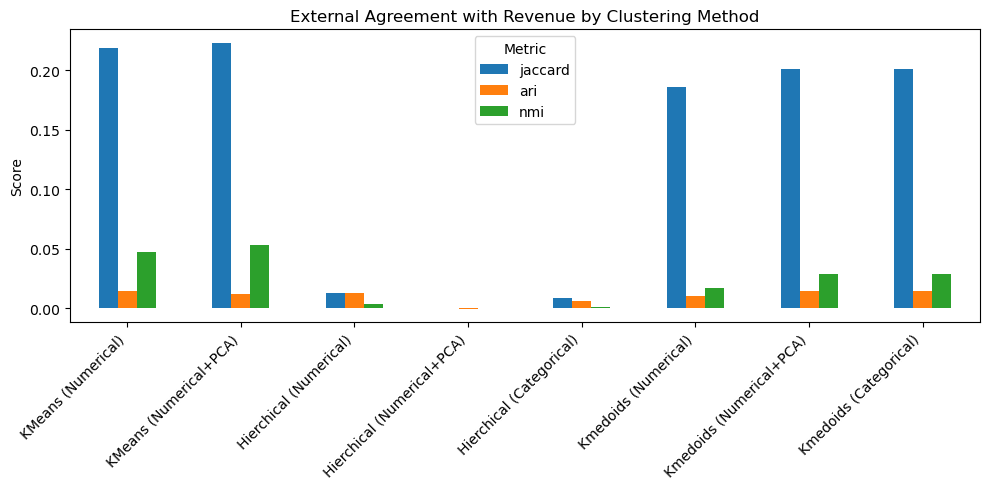

In [ ]:
metrics_to_plot = ['jaccard', 'ari', 'nmi']
all_results_df[metrics_to_plot].plot(kind='bar', figsize=(10,5))
plt.title('External Agreement with Revenue by Clustering Method')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

Text(5, 5, 'KMeans (Numerical)')

Text(5, 5, 'KMeans (Numerical+PCA)')

Text(5, 5, 'Hierchical (Numerical)')

Text(5, 5, 'Hierchical (Numerical+PCA)')

...

Text(5, 5, 'Kmedoids (Numerical+PCA)')

Text(5, 5, 'Kmedoids (Categorical)')

Text(0.5, 0, 'Silhouette Score (internal quality)')

Text(0, 0.5, 'Jaccard Index (agreement with Revenue)')

Text(0.5, 1.0, 'Internal Quality vs External Alignment')

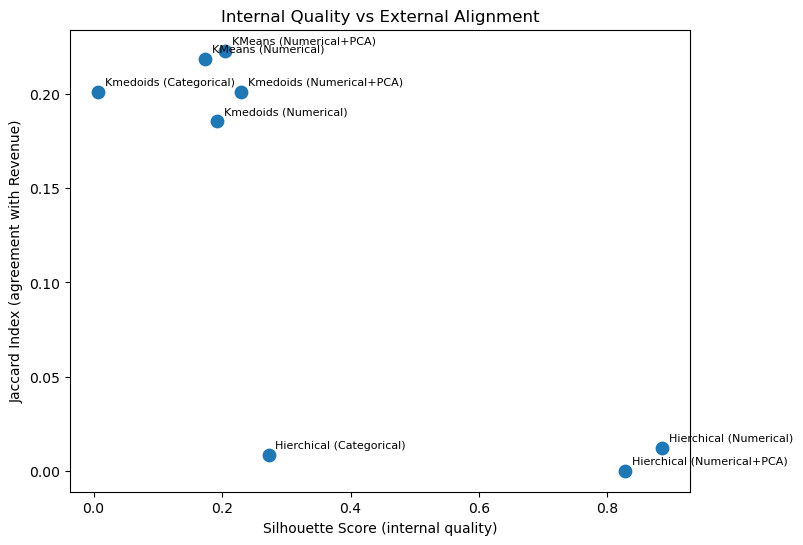

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(all_results_df['silhouette'], all_results_df['jaccard'], s=80)

for method in all_results_df.index:
    plt.annotate(method, (all_results_df.loc[method, 'silhouette'], all_results_df.loc[method, 'jaccard']),
                 fontsize=8, xytext=(5,5), textcoords='offset points')

plt.xlabel('Silhouette Score (internal quality)')
plt.ylabel('Jaccard Index (agreement with Revenue)')
plt.title('Internal Quality vs External Alignment')
plt.show()

We select K-Means (Numerical+PCA) as our best clustering method based on Jaccard Index (0.223)

Among all clustering configurations tested, K-Means (Numerical+PCA) achieves the best alignment with the true 
Revenue labels (Jaccard = 0.223, NMI = 0.053), and is essentially tied for best ARI (0.012). This is despite 
NOT having the highest internal cluster quality — Hierarchical clustering achieves dramatically higher 
silhouette scores (up to 0.894), yet its Jaccard/ARI/NMI are near zero, indicating it identifies a compact, 
well-separated structure in the data that is unrelated to purchasing behavior. Hierarchical's high reported 
accuracy (~0.84) is likewise misleading, reflecting the ~85% majority-class baseline rather than genuine 
predictive skill, since both Jaccard and ARI are close to zero. We therefore select K-Means (Numerical+PCA) as 
our representative clustering-based approach for the final comparison against our best supervised classifier.

## Best classifier vs Best clustering method

We have observed that the best clustering method performs best with numerical features + PCA dimensionality reduction. Let us now see how the best classifier performs with NUM_PCA.
We will train the best classifer on the training dataset and then compare the performance with the test set

In [ ]:
#we will fit the logistic regression with the same variable that was used to the best clustring method in order to compare the two models:
#target variable:
y_train=train_data['Revenue'].astype(int)
y_test=test_data['Revenue'].astype(int)

#selecting the number of components as before:
pca = PCA(n_components=6)

#scaling for train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data[numerical_cols])
X_train_pca = pca.fit_transform(X_train_scaled)

X_test_scaled = scaler.transform(test_data[numerical_cols])   # note: transform, not fit_transform
X_test_pca = pca.transform(X_test_scaled)  

In [ ]:
#logistic regression fitting:
classifier = LogisticRegression(max_iter=1000, class_weight='balanced')
classifier.fit(X_train_pca, y_train)

#prediction:
classifier_pred = classifier.predict(X_test_pca)


classifier_proba = classifier.predict_proba(X_test_pca)[:, 1]

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
#evaluation for logistic regression:
lr_results = {
    'Method': 'Logistic Regression (Supervised)',
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'roc_auc': roc_auc_score(y_test, y_proba_lr)
}
print(lr_results)
lr_results

len(pred_labels_NUM_PCAmedoids)

{'Method': 'Logistic Regression (Supervised)', 'accuracy': 0.881570408825438, 'precision': 0.5814696485623003, 'recall': 0.7794432548179872, 'f1': 0.6660567246111619, 'roc_auc': np.float64(0.9129548274040805)}


{'Method': 'Logistic Regression (Supervised)',
 'accuracy': 0.881570408825438,
 'precision': 0.5814696485623003,
 'recall': 0.7794432548179872,
 'f1': 0.6660567246111619,
 'roc_auc': np.float64(0.9129548274040805)}

9248

In [ ]:
#best clusering method evaluation:

#Since clustering is an unsupervised learning technique and does not directly produce class predictions, we defined a function that assigns a class label to each cluster according 
# to the majority class of its training samples. This mapping enables the evaluation of the clustering algorithm as a classifier.
def clusters_to_predictions(cluster_labels, y_true):
    cluster_to_class = {}
    cluster_to_prob = {}
    for c in np.unique(cluster_labels):
        mask = cluster_labels == c
        cluster_to_class[c] = pd.Series(y_true[mask]).mode()[0]
        cluster_to_prob[c] = pd.Series(y_true[mask]).mean()  # proportion of buyers, used as pseudo-probability
    predictions = np.array([cluster_to_class[c] for c in cluster_labels])
    probabilities = np.array([cluster_to_prob[c] for c in cluster_labels])
    return predictions, probabilities, cluster_to_class

# pred_labels_NUM_PCA_medoids = your K-Medoids cluster assignments on training data (NUM + PCA)
y_pred_kmeans, y_proba_kmeans, mapping = clusters_to_predictions(pred_labels_NUM_PCA_kmeans, y)
print("Cluster -> class mapping:", mapping)

Cluster -> class mapping: {np.int32(0): np.int64(0), np.int32(1): np.int64(0)}


In [ ]:
test_clusters_km = kmeans_NUM_PCA.predict(X_test_pca)  # assign test points to existing clusters

y_pred_kmeans_test = np.array([mapping[c] for c in test_clusters_km])

# For probabilities, build the buyer-proportion dict from training too
cluster_probs = {}
for c in np.unique(pred_labels_NUM_PCA_kmeans):
    mask = pred_labels_NUM_PCA_kmeans == c
    cluster_probs[c] = pd.Series(y)[mask].mean()

y_proba_kmeans_test = np.array([cluster_probs[c] for c in test_clusters_km])

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
#summarizing the results:
kmeans_results = {
    'Method': 'K-Means (NUM + PCA) as Classifier',
    'accuracy': accuracy_score(y_test, y_pred_kmeans_test),
    'precision': precision_score(y_test, y_pred_kmeans_test),
    'recall': recall_score(y_test, y_pred_kmeans_test),
    'f1': f1_score(y_test, y_pred_kmeans_test),
    'roc_auc': roc_auc_score(y_test, y_pred_kmeans_test)
}

kmeans_results

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'Method': 'K-Means (NUM + PCA) as Classifier',
 'accuracy': 0.8484750162232316,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': np.float64(0.5)}

Text(0.5, 1.0, 'K-Means Clusters (PC1 vs PC2)')

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

Text(0.5, 1.0, 'True Revenue Labels (PC1 vs PC2)')

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

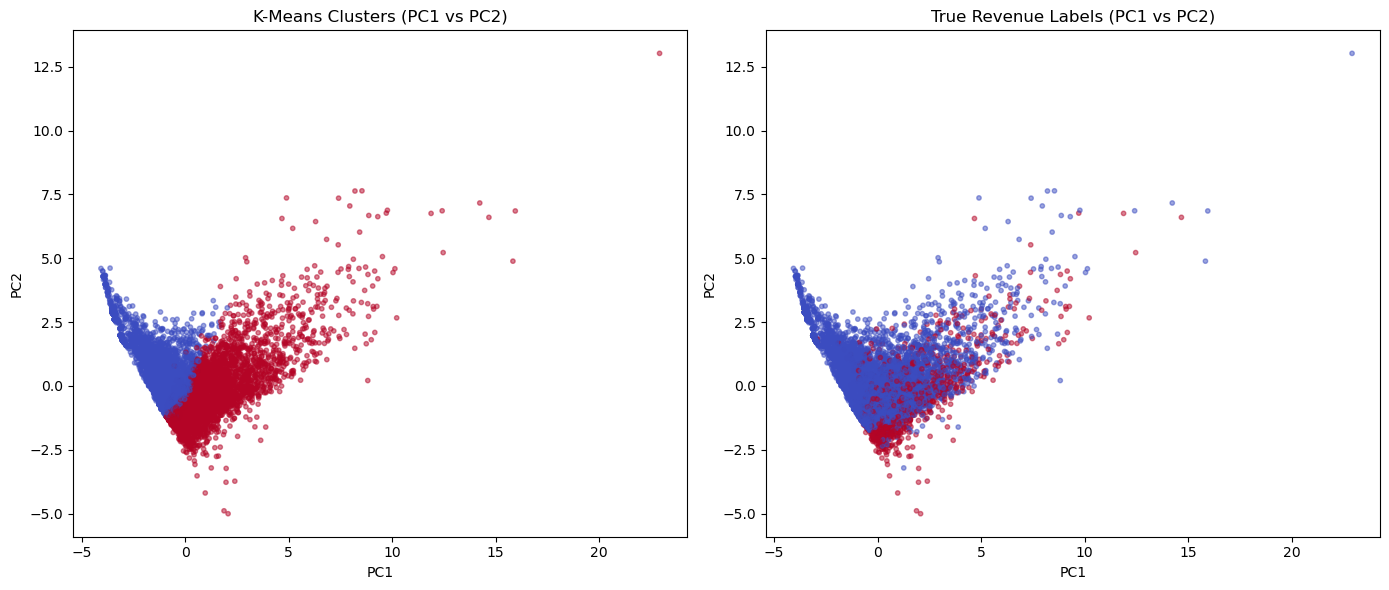

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: colored by predicted cluster
axes[0].scatter(X_NUMpca_array[:,0], X_NUMpca_array[:,1], c=pred_labels_NUM_PCA_kmeans, cmap='coolwarm', alpha=0.5, s=10)
axes[0].set_title('K-Means Clusters (PC1 vs PC2)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Right: colored by TRUE Revenue label
axes[1].scatter(X_NUMpca_array[:,0], X_NUMpca_array[:,1], c=y, cmap='coolwarm', alpha=0.5, s=10)
axes[1].set_title('True Revenue Labels (PC1 vs PC2)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

The K-Means clustering produces two well-separated groups that follow the direction of maximum variance in the numerical features (PC1), but this partition does not align with the true Revenue labels, which appear scattered across both clusters without forming a distinct region. This suggests that the geometric structure captured by PCA is not predictive of purchasing behavior, likely because Revenue depends on a more complex combination of factors, including categorical variables not included in this PCA. As a result, low agreement is expected between the unsupervised clusters and the ground truth (e.g., low ARI/NMI scores).

In [ ]:
comparison_df = pd.DataFrame([kmeans_results, lr_results])
comparison_df = comparison_df.set_index('Method')
comparison_df

,accuracy,precision,recall,f1,roc_auc
Method,,,,,
K-Means (NUM + PCA) as Classifier,0.848475,0.00000,0.000000,0.000000,0.500000
Logistic Regression (Supervised),0.881570,0.58147,0.779443,0.666057,0.912955


<BarContainer object of 5 artists>

<BarContainer object of 5 artists>

[Text(0, 0, 'accuracy'),
 Text(1, 0, 'precision'),
 Text(2, 0, 'recall'),
 Text(3, 0, 'f1'),
 Text(4, 0, 'roc_auc')]

Text(0, 0.5, 'Score')

(0.0, 1.0)

Text(0.5, 1.0, 'Metrics comparison: K-Means(NUM+PCA) vs Logistic Regression')

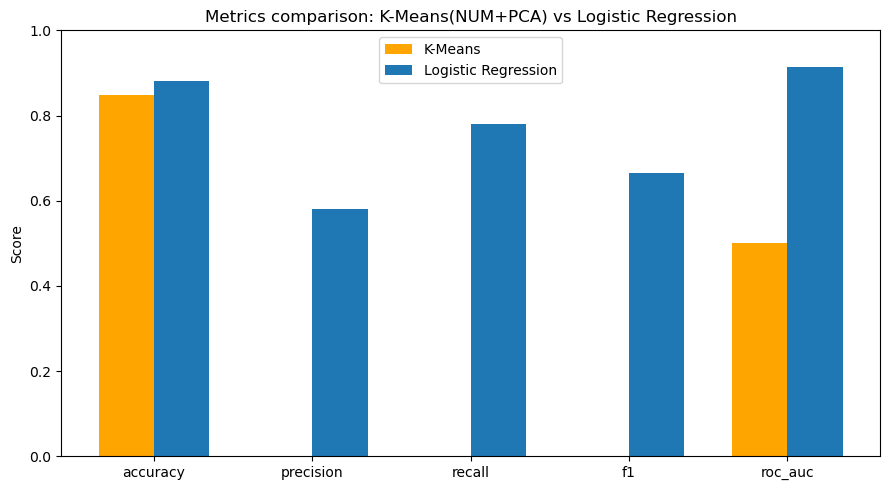

In [ ]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, comparison_df.loc['K-Means (NUM + PCA) as Classifier', metrics], width, label='K-Means', color='orange')
ax.bar(x + width/2, comparison_df.loc['Logistic Regression (Supervised)', metrics], width, label='Logistic Regression', color='tab:blue')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Metrics comparison: K-Means(NUM+PCA) vs Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'ROC Curve: Best Classifier vs Best Clustering Method')

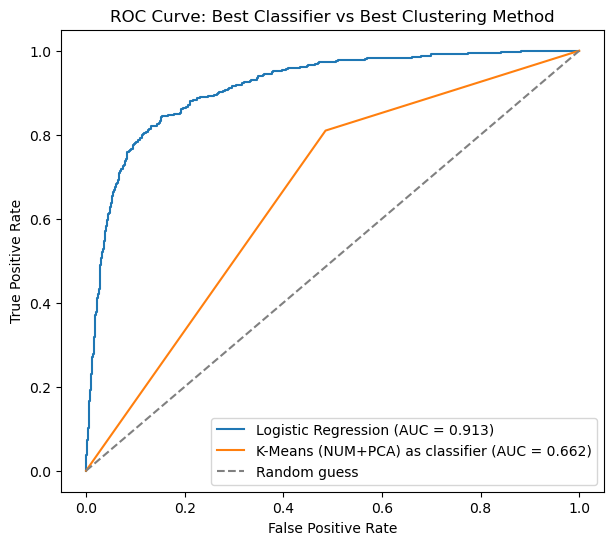

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression — evaluated on the test set
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# K-Means (NUM+PCA) as classifier — make sure y_proba_kmeans_test comes from TEST-set cluster assignments
fpr_km, tpr_km, _ = roc_curve(y, y_proba_kmeans)
auc_km = auc(fpr_km, tpr_km)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='tab:blue')
plt.plot(fpr_km, tpr_km, label=f'K-Means (NUM+PCA) as classifier (AUC = {auc_km:.3f})', color='tab:orange')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Best Classifier vs Best Clustering Method')
plt.legend()
plt.show()

f1 score = 0 means that this model never predicted the positive class but high accuracy means that the model predicted all of the negative classes. This is due to the imbalance between the two classes (Revenue true and false). 

As a final consideration, when using only the numerical variables, Logistic Regression clearly outperformed K-Means across all evaluation metrics. This indicates that, for this dataset, predicting Revenue is better addressed as a supervised classification task rather than an unsupervised clustering one. Specifically, the Logistic Regression model built on the features selected in Task 2 provides the best overall performance summary, and is therefore the recommended approach for this prediction task

---
---
---

# CONCLUSION

BASTAAAAA NON HO CAPITO UNA SEGAAAAAAAAA

---
---
---